In [1]:
# ============================================================
# Cell 1: Imports
# ============================================================
import os, time, random, json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from tensorflow.keras.datasets import mnist

from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("NumPy      :", np.__version__)
print("Matplotlib :", matplotlib.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.1.3
Matplotlib : 3.10.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# Cell 2: Global setup
# ============================================================

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---------- Output directory ----------
OUT_DIR = Path("/content/outputs/plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Font: Times New Roman, size 16 ----------
FONT_PATH = "/content/times.ttf"
assert os.path.exists(FONT_PATH), f"{FONT_PATH} not found - upload times.ttf to /content first."

font_manager.fontManager.addfont(FONT_PATH)
FONT_NAME = font_manager.FontProperties(fname=FONT_PATH).get_name()
FONT_SIZE = 16

plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.titlesize": FONT_SIZE,
    "mathtext.fontset": "stix",        # Times-like math text
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "ps.fonttype": 42,                 # embed TrueType fonts in EPS
    "pdf.fonttype": 42,                # embed TrueType fonts in PDF
    "figure.autolayout": False,
})
print(f"Font loaded: {FONT_NAME}, size {FONT_SIZE}")

# ---------- Experiment configuration (from the lab sheet) ----------
CFG = {
    # data
    "n_train": 10_000,
    "n_test": 2_000,
    "val_split": 0.1,
    "img_shape": (28, 28, 1),
    # basic FC autoencoder
    "latent_dim": 16,
    "lr": 1e-3,
    "batch_size": 128,
    "epochs": 20,
    # latent dimension study
    "latent_dims": [2, 8, 16, 32],
    # denoising
    "gauss_sigmas": [0.1, 0.2, 0.3],
    "sp_levels": [0.05, 0.10, 0.20],
    # VAE
    "vae_latent_dim": 2,
    "n_generated": 25,
    "interp_alphas": np.linspace(0, 1, 11),
    # additional exercises
    "cae_latent_dims": [4, 8, 16, 32],
    "vae_latent_dims_ex": [2, 8],
    "kl_weights": [0.5, 1.0, 2.0, 5.0],   # exercise 6 (beta-VAE style)
}

# ---------- Plot saver: EPS if < 100 KB, else PDF ----------
SIZE_LIMIT = 100 * 1024   # 100 KB

def save_fig(fig, name, show=True):
    """Save as EPS if the file is under 100 KB; otherwise replace with PDF."""
    eps_path = OUT_DIR / f"{name}.eps"
    pdf_path = OUT_DIR / f"{name}.pdf"
    for p in (eps_path, pdf_path):
        if p.exists():
            p.unlink()

    fig.savefig(eps_path, format="eps")
    size = eps_path.stat().st_size
    if size <= SIZE_LIMIT:
        final = eps_path
    else:
        eps_path.unlink()
        fig.savefig(pdf_path, format="pdf")
        final = pdf_path
    print(f"[saved] {final.name}  ({final.stat().st_size/1024:.1f} KB)"
          f"{'' if final.suffix == '.eps' else f'  <- EPS was {size/1024:.1f} KB, used PDF'}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return final

# ---------- Result tracking (for the consolidated tables) ----------
RESULTS = {}      # RESULTS["FC-AE"] = {"MSE":..., "MAE":..., "SSIM":..., "Params":..., "Time":...}
HISTORIES = {}    # Keras training histories keyed by model name

def log_result(model_name, **metrics):
    RESULTS.setdefault(model_name, {}).update(metrics)

def count_params(model):
    return int(model.count_params())

class Timer:
    """with Timer() as t: ...; t.elapsed -> seconds"""
    def __enter__(self):
        self.start = time.perf_counter(); return self
    def __exit__(self, *a):
        self.elapsed = time.perf_counter() - self.start

print("Setup complete. Plots will be saved to:", OUT_DIR)

Font loaded: Times New Roman, size 16
Setup complete. Plots will be saved to: /content/outputs/plots


In [4]:
# ============================================================
# Cell 3: Data, metric helpers, noise functions
# ============================================================
from IPython.display import display
from matplotlib.ticker import MaxNLocator
from scipy.stats import norm
from sklearn.decomposition import PCA

CFG.update({"cae_epochs": 20, "dae_epochs": 20, "vae_epochs": 30, "eval_subset": 300})
LR, BATCH = CFG["lr"], CFG["batch_size"]
IMG_SHAPE = CFG["img_shape"]
TAB_DIR = Path("/content/outputs/tables"); TAB_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"legend.framealpha": 1.0, "legend.frameon": False,
                     "legend.title_fontsize": FONT_SIZE})

# ---------- Data ----------
(x_all, y_all), (x_test_all, y_test_all) = mnist.load_data()
rng = np.random.default_rng(SEED)
tr_idx = rng.choice(len(x_all), CFG["n_train"], replace=False)
te_idx = rng.choice(len(x_test_all), CFG["n_test"], replace=False)

x_pool = (x_all[tr_idx].astype("float32") / 255.0)[..., None]
y_pool = y_all[tr_idx]
x_te = (x_test_all[te_idx].astype("float32") / 255.0)[..., None]
y_te = y_test_all[te_idx]

x_tr, x_va, y_tr, y_va = train_test_split(
    x_pool, y_pool, test_size=CFG["val_split"], random_state=SEED, stratify=y_pool)
print("train", x_tr.shape, "| val", x_va.shape, "| test", x_te.shape,
      "| range", float(x_tr.min()), float(x_tr.max()))

# one test image per digit, reused in every image grid
SHOW_IDX = np.array([np.where(y_te == d)[0][0] for d in range(10)])

MODELS, RECON = {}, {}     # trained models / test reconstructions

# ---------- Metrics ----------
def per_image_mse(x, xh): return np.mean((x - xh) ** 2, axis=(1, 2, 3))
def per_image_mae(x, xh): return np.mean(np.abs(x - xh), axis=(1, 2, 3))
def per_image_ssim(x, xh):
    return np.array([ssim(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xh)])

def evaluate_recon(x, xh):
    return {"MSE": float(per_image_mse(x, xh).mean()),
            "MAE": float(per_image_mae(x, xh).mean()),
            "SSIM": float(per_image_ssim(x, xh).mean())}

# ---------- Noise ----------
NOISE = {"gaussian": CFG["gauss_sigmas"], "sp": CFG["sp_levels"]}
MAIN_NOISE = {"gaussian": 0.2, "sp": 0.10}          # level used to TRAIN the main denoisers
NAMES = {"gaussian": "Gaussian", "sp": "Salt-and-pepper"}
TEST_SEED = 1234

def corrupt_np(x, kind, level, seed=0):
    r = np.random.default_rng(seed)
    if kind == "gaussian":
        return np.clip(x + r.normal(0.0, level, x.shape), 0, 1).astype("float32")
    u = r.random(x.shape)
    out = x.copy()
    out[u < level / 2] = 0.0                          # pepper
    out[(u >= level / 2) & (u < level)] = 1.0         # salt
    return out.astype("float32")

def corrupt_tf(x, kind, level):
    if kind == "gaussian":
        return tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=level), 0.0, 1.0)
    u = tf.random.uniform(tf.shape(x))
    x = tf.where(u < level / 2, 0.0, x)
    return tf.where((u >= level / 2) & (u < level), 1.0, x)

def noisy_dataset(x, kind, level, batch_size):
    """Fresh noise every epoch; target is always the clean image."""
    ds = tf.data.Dataset.from_tensor_slices(x).shuffle(len(x), seed=SEED).batch(batch_size)
    return ds.map(lambda c: (corrupt_tf(c, kind, level), c), num_parallel_calls=tf.data.AUTOTUNE)

def make_eval_sets(x_ref, kind):
    """Fixed noisy validation sets, one per noise level (used for epoch-wise curves)."""
    return {str(l): (corrupt_np(x_ref, kind, l, seed=SEED + i), x_ref)
            for i, l in enumerate(NOISE[kind])}

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train (9000, 28, 28, 1) | val (1000, 28, 28, 1) | test (2000, 28, 28, 1) | range 0.0 1.0


In [5]:
# ============================================================
# Cell 4: Plot / table helpers
# ============================================================
def save_table(df, name, float_fmt="%.4f"):
    df.to_csv(TAB_DIR / f"{name}.csv")
    df.to_latex(TAB_DIR / f"{name}.tex", float_format=float_fmt, escape=True)
    print(f"[table] {name}")
    display(df)

STYLES = [("tab:blue", "-", "o"), ("tab:red", "--", "s"), ("tab:green", "-.", "^"),
          ("tab:orange", ":", "D"), ("tab:purple", "-", "v"), ("tab:brown", "--", "P")]
KEYS_METRIC = [("val_mse", "Validation MSE"), ("val_mae", "Validation MAE"),
               ("val_ssim", "Validation SSIM")]

def eval_to_hist(rec):
    return {"val_mse": rec["mse"], "val_mae": rec["mae"], "val_ssim": rec["ssim"]}

def _legend_below(fig, ax, ncol):
    h, l = ax.get_legend_handles_labels()
    fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=min(len(l), ncol))

def plot_epochwise(hists, fname, keys=KEYS_METRIC, styles=None, panel_w=6.2, logy=False, ncol=4):
    """One panel per metric, one curve per configuration, x-axis = epoch."""
    fig, axes = plt.subplots(1, len(keys), figsize=(panel_w * len(keys), 4.8), squeeze=False)
    axes = axes[0]
    for j, (name, h) in enumerate(hists.items()):
        col, ls, mk = (styles or {}).get(name, STYLES[j % len(STYLES)])
        for ax, (k, _) in zip(axes, keys):
            y = h[k]
            ax.plot(np.arange(1, len(y) + 1), y, color=col, ls=ls, marker=mk, ms=4,
                    markevery=max(1, len(y) // 10), label=name)
    for ax, (k, lab) in zip(axes, keys):
        ax.set_xlabel("Epoch"); ax.set_ylabel(lab); ax.grid(True, lw=0.4)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        if logy and k != "val_ssim":
            ax.set_yscale("log")
    fig.tight_layout()
    _legend_below(fig, axes[0], ncol)
    return save_fig(fig, fname)

def plot_train_val(hist, panels, fname, panel_w=6.2):
    fig, axes = plt.subplots(1, len(panels), figsize=(panel_w * len(panels), 4.8), squeeze=False)
    for ax, (k, lab) in zip(axes[0], panels):
        ep = np.arange(1, len(hist[k]) + 1)
        ax.plot(ep, hist[k], "-", color="tab:blue", label="Training")
        ax.plot(ep, hist["val_" + k], "--", color="tab:red", label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel(lab); ax.grid(True, lw=0.4); ax.legend()
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    fig.tight_layout()
    return save_fig(fig, fname)

def show_grid(rows, fname, col_titles=None, cell=1.6):
    """rows: list of (label, images[, cmap, vmax]); images shaped (n,28,28,1)."""
    nr, nc = len(rows), len(rows[0][1])
    fig, axes = plt.subplots(nr, nc, figsize=(cell * nc + 1.5, cell * nr + (0.7 if col_titles else 0)),
                             squeeze=False)
    for r, (label, imgs, *rest) in enumerate(rows):
        cmap = rest[0] if rest else "gray"
        vmax = rest[1] if len(rest) > 1 else 1.0
        for c in range(nc):
            ax = axes[r, c]
            ax.imshow(imgs[c].squeeze(), cmap=cmap, vmin=0, vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0 and col_titles is not None:
                ax.set_title(col_titles[c])
            if c == 0:
                ax.set_ylabel(label, rotation=0, ha="right", va="center", labelpad=10)
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    return save_fig(fig, fname)

def err_row(label, x, xh):
    e = np.abs(x - xh)
    return (label, e, "hot", float(max(e.max(), 1e-6)))

def make_canvas(imgs, nrow, ncol):
    return imgs[:nrow * ncol, ..., 0].reshape(nrow, ncol, 28, 28).transpose(0, 2, 1, 3).reshape(nrow * 28, ncol * 28)

def gallery(imgs, nrow, ncol, fname, cell=0.9):
    fig, ax = plt.subplots(figsize=(cell * ncol, cell * nrow))
    ax.imshow(make_canvas(imgs, nrow, ncol), cmap="gray", vmin=0, vmax=1); ax.axis("off")
    return save_fig(fig, fname)

DIGIT_MARKERS = ["o", "s", "^", "v", "D", "P", "X", "*", "<", ">"]
def scatter_latent(ax, z, y, s=12):
    cm = plt.get_cmap("tab10")
    for d in range(10):
        m = y == d
        ax.scatter(z[m, 0], z[m, 1], s=s, color=cm(d), marker=DIGIT_MARKERS[d], label=str(d))

In [6]:
# ============================================================
# Cell 5: Model builders + training utilities
# ============================================================
def build_fc_ae(dz, name=None):
    """784-128-32-dz-32-128-784. Latent layer is linear; hidden ReLU; output sigmoid."""
    inp = keras.Input(IMG_SHAPE)
    x = layers.Flatten()(inp)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(dz, name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(784, activation="sigmoid")(x)
    return keras.Model(inp, layers.Reshape(IMG_SHAPE)(x), name=name or f"fc_ae_dz{dz}")

def build_cae(dz=None, decoder_type="upsample", name=None):
    """dz=None -> lab-sheet CAE (7x7x64 feature-map latent).
       dz=int  -> Flatten-Dense(dz)-Dense-Reshape bottleneck (Exercise 1).
       decoder_type: 'upsample' (UpSampling2D+Conv2D) or 'transpose' (Conv2DTranspose, Exercise 4)."""
    inp = keras.Input(IMG_SHAPE)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    if dz is None:
        x = layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_map")(x)
    else:
        x = layers.Flatten()(x)
        x = layers.Dense(dz, name="latent")(x)
        x = layers.Dense(7 * 7 * 64, activation="relu")(x)
        x = layers.Reshape((7, 7, 64))(x)
    if decoder_type == "upsample":
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.UpSampling2D(2)(x)
        out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    else:
        x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
        out = layers.Conv2DTranspose(1, 3, strides=2, activation="sigmoid", padding="same")(x)
    return keras.Model(inp, out, name=name or "cae")

# ---------- VAE ----------
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * eps, eps ~ N(0, I)."""
    def __init__(self, **kw):
        super().__init__(**kw)
        self.seed_generator = keras.random.SeedGenerator(SEED)
    def call(self, inputs):
        mu, logvar = inputs
        eps = keras.random.normal(keras.ops.shape(mu), seed=self.seed_generator)
        return mu + keras.ops.exp(0.5 * logvar) * eps

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder, self.beta = encoder, decoder, float(beta)
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec_loss")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, x):                      # deterministic reconstruction from mu
        mu, _, _ = self.encoder(x)
        return self.decoder(mu)

    def per_image_losses(self, x, training=False):
        x = tf.convert_to_tensor(x, tf.float32)
        mu, logvar, z = self.encoder(x, training=training)
        xh = self.decoder(z, training=training)
        rec = tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=[1, 2])   # BCE summed over pixels
        kl = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
        return rec, kl

    def _update(self, rec, kl):
        self.loss_tracker.update_state(tf.reduce_mean(rec + self.beta * kl))
        self.rec_tracker.update_state(tf.reduce_mean(rec))
        self.kl_tracker.update_state(tf.reduce_mean(kl))
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl = self.per_image_losses(x, training=True)
            loss = tf.reduce_mean(rec + self.beta * kl)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return self._update(rec, kl)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        rec, kl = self.per_image_losses(x, training=False)
        return self._update(rec, kl)

def build_vae(dz, beta=1.0, name=None):
    ei = keras.Input(IMG_SHAPE)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(ei)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    mu = layers.Dense(dz, name="mu")(x)
    logvar = layers.Dense(dz, name="log_var")(x)
    z = Sampling(name="z")([mu, logvar])
    enc = keras.Model(ei, [mu, logvar, z], name="encoder")

    di = keras.Input((dz,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(di)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    do = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    dec = keras.Model(di, do, name="decoder")

    vae = VAE(enc, dec, beta, name=name or f"vae_dz{dz}")
    vae(np.zeros((1,) + IMG_SHAPE, "float32"))     # build weights
    return vae

def count_vae_params(vae): return int(vae.encoder.count_params() + vae.decoder.count_params())

# ---------- Epoch-wise evaluation callback ----------
class EpochEval(callbacks.Callback):
    """After every epoch: MSE / MAE / SSIM (skimage) on a fixed validation subset.
       sets = {label: (model_input, clean_target)}."""
    def __init__(self, sets, n=CFG["eval_subset"]):
        super().__init__()
        self.sets = {k: (tf.convert_to_tensor(a[:n]), np.asarray(b[:n])) for k, (a, b) in sets.items()}
        self.rec = {k: {"mse": [], "mae": [], "ssim": []} for k in sets}
    def on_epoch_end(self, epoch, logs=None):
        for k, (xi, xt) in self.sets.items():
            m = evaluate_recon(xt, np.asarray(self.model(xi, training=False)))
            for key, v in m.items():
                self.rec[k][key.lower()].append(v)

def predict(model, x): return np.asarray(model.predict(x, batch_size=256, verbose=0))

def compile_ae(model):
    model.compile(optimizer=optimizers.Adam(LR), loss="binary_crossentropy",
                  metrics=[keras.metrics.MeanSquaredError(name="mse"),
                           keras.metrics.MeanAbsoluteError(name="mae")])

def train_ae(model, name, x_train, x_val, epochs, batch_size=BATCH, noise=None, extra_eval=None):
    """noise=None: plain AE. noise=(kind, level): denoising AE (fresh noise each epoch,
       fixed noisy validation set, clean target)."""
    compile_ae(model)
    if noise is None:
        x_val_in = x_val
        data = dict(x=x_train, y=x_train, batch_size=batch_size, shuffle=True)
    else:
        kind, level = noise
        x_val_in = corrupt_np(x_val, kind, level, seed=SEED)
        data = dict(x=noisy_dataset(x_train, kind, level, batch_size))
    sets = {"val": (x_val_in, x_val)}
    if extra_eval: sets.update(extra_eval)
    cb = EpochEval(sets)
    with Timer() as t:
        h = model.fit(**data, validation_data=(x_val_in, x_val), epochs=epochs,
                      callbacks=[cb], verbose=0)
    hist = dict(h.history)
    hist["val_ssim"] = cb.rec["val"]["ssim"]        # SSIM on a fixed val subset
    hist["eval"], hist["time"] = cb.rec, t.elapsed
    HISTORIES[name] = hist
    print(f"[trained] {name}: params={count_params(model):,}  time={t.elapsed:.1f}s  "
          f"final val_loss={hist['val_loss'][-1]:.4f}")
    return hist

def train_vae(dz, beta, name, epochs=CFG["vae_epochs"]):
    vae = build_vae(dz, beta, name=name.replace(" ", "_"))
    vae.compile(optimizer=optimizers.Adam(LR))
    tr = tf.data.Dataset.from_tensor_slices(x_tr).shuffle(len(x_tr), seed=SEED).batch(BATCH)
    va = tf.data.Dataset.from_tensor_slices(x_va).batch(BATCH)
    cb = EpochEval({"val": (x_va, x_va)})
    with Timer() as t:
        h = vae.fit(tr, validation_data=va, epochs=epochs, callbacks=[cb], verbose=0)
    hist = dict(h.history)
    for k in ("mse", "mae", "ssim"):
        hist["val_" + k] = cb.rec["val"][k]
    hist["eval"], hist["time"] = cb.rec, t.elapsed
    HISTORIES[name] = hist
    print(f"[trained] {name}: params={count_vae_params(vae):,}  time={t.elapsed:.1f}s  "
          f"final val_loss={hist['val_loss'][-1]:.2f}")
    return vae, hist

def vae_losses_np(vae, x, bs=500):
    recs, kls = [], []
    for i in range(0, len(x), bs):
        r, k = vae.per_image_losses(x[i:i + bs], training=False)
        recs.append(r.numpy()); kls.append(k.numpy())
    return np.concatenate(recs), np.concatenate(kls)

def evaluate_vae(vae, x):
    """Rec/KL/Total (per-image, nats) from sampled z; MSE/MAE/SSIM from the mean reconstruction."""
    rec, kl = vae_losses_np(vae, x)
    xh = predict(vae, x)
    m = {"Rec loss": float(rec.mean()), "KL loss": float(kl.mean()),
         "Total loss": float((rec + vae.beta * kl).mean()), **evaluate_recon(x, xh)}
    return m, xh

[trained] FC-AE: params=211,040  time=14.8s  final val_loss=0.1262
{'MSE': 0.02068, 'MAE': 0.05651, 'SSIM': 0.76262}
[saved] plot1_original_vs_reconstructed.pdf  (81.6 KB)  <- EPS was 22784.9 KB, used PDF


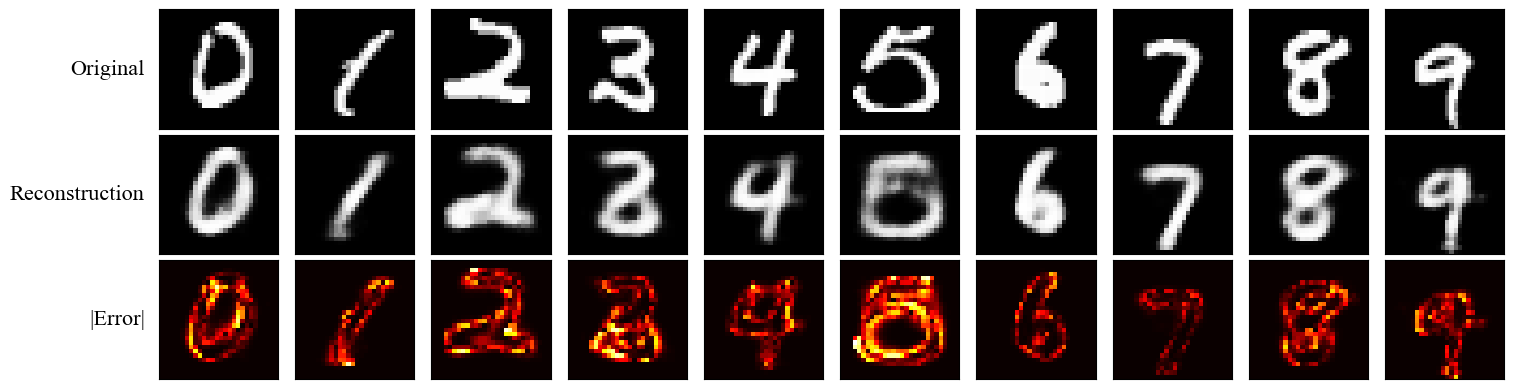

[saved] plot2_fcae_train_val_loss.eps  (93.2 KB)


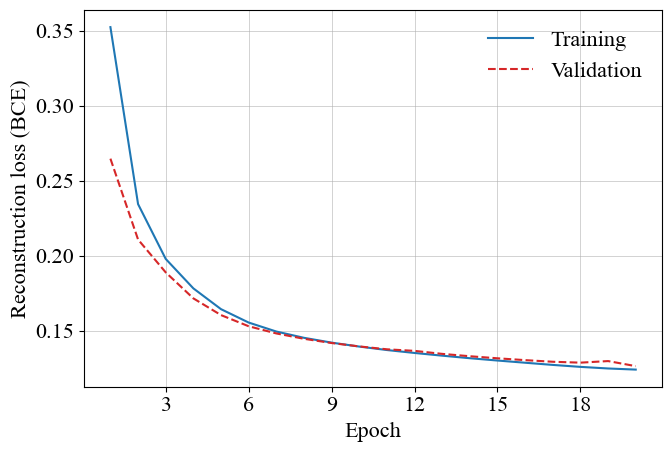

[table] table_fcae_metrics


,Value
Test MSE,0.020679
Test MAE,0.056510
Mean SSIM,0.762617


In [7]:
# ============================================================
# Cell 6: FC autoencoder - training, metrics, Plot 1, Plot 2
# ============================================================
fc = build_fc_ae(CFG["latent_dim"], name="fc_ae")
h_fc = train_ae(fc, "FC-AE", x_tr, x_va, CFG["epochs"])
MODELS["FC-AE"] = fc

xh_fc = predict(fc, x_te); RECON["FC-AE"] = xh_fc
m_fc = evaluate_recon(x_te, xh_fc)
log_result("FC Autoencoder", **m_fc, Params=count_params(fc), Time=h_fc["time"])
print({k: round(v, 5) for k, v in m_fc.items()})

# Plot 1: original / reconstruction / error
show_grid([("Original", x_te[SHOW_IDX]),
           ("Reconstruction", xh_fc[SHOW_IDX]),
           err_row("|Error|", x_te[SHOW_IDX], xh_fc[SHOW_IDX])],
          "plot1_original_vs_reconstructed")

# Plot 2: train / val loss
plot_train_val(h_fc, [("loss", "Reconstruction loss (BCE)")], "plot2_fcae_train_val_loss", panel_w=7)

table = pd.DataFrame.from_dict({"Test MSE": m_fc["MSE"], "Test MAE": m_fc["MAE"],
                                "Mean SSIM": m_fc["SSIM"]}, orient="index", columns=["Value"])
save_table(table, "table_fcae_metrics", "%.5f")

[trained] FC-AE-dz2: params=210,130  time=14.7s  final val_loss=0.2015
[trained] FC-AE-dz8: params=210,520  time=15.9s  final val_loss=0.1388


[trained] FC-AE-dz32: params=212,080  time=15.6s  final val_loss=0.1198
[table] table_latent_dim_fcae


,MSE,MAE,SSIM,Params,Time
Latent dim,,,,,
2,0.047278,0.109741,0.476088,210130,14.667599
8,0.024986,0.065006,0.720812,210520,15.903097
16,0.020679,0.056510,0.762617,211040,14.781381
32,0.018316,0.051453,0.787556,212080,15.550896


[saved] plot_latdim_epochwise.pdf  (35.8 KB)  <- EPS was 119.6 KB, used PDF


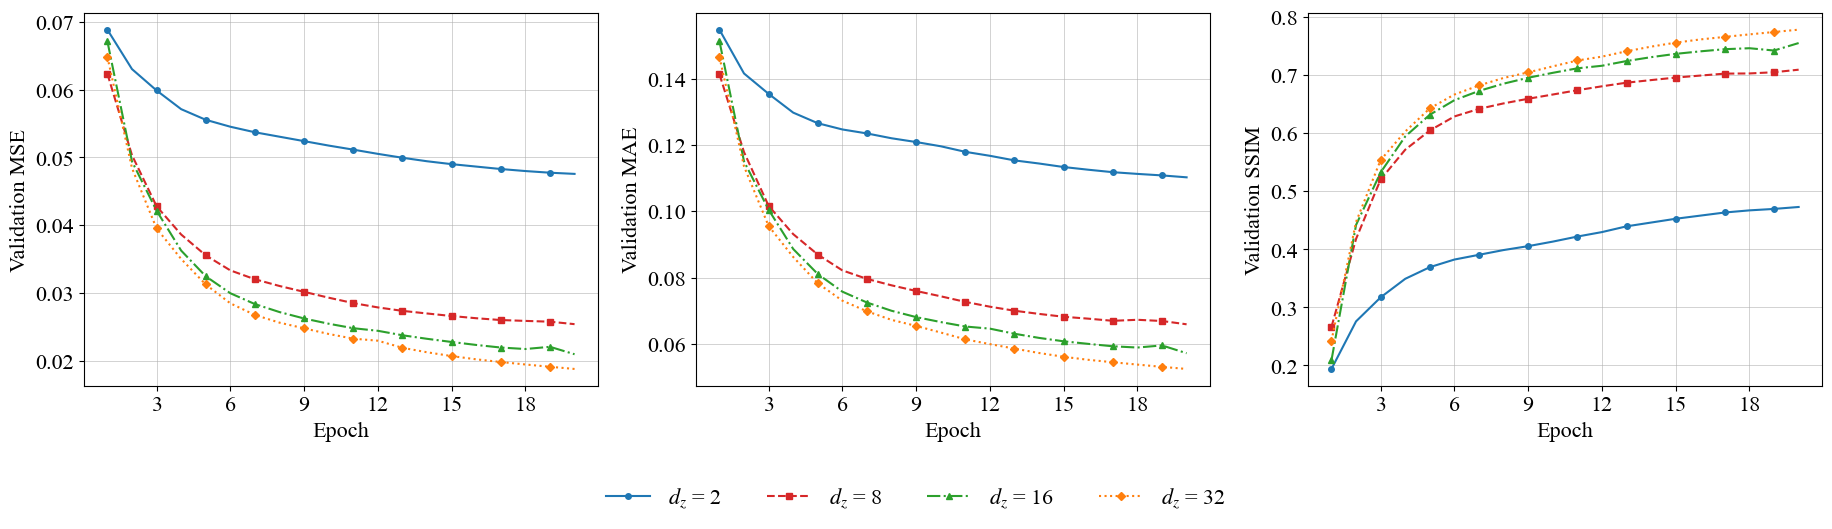

[saved] plot_latdim_vs_mse.eps  (79.6 KB)


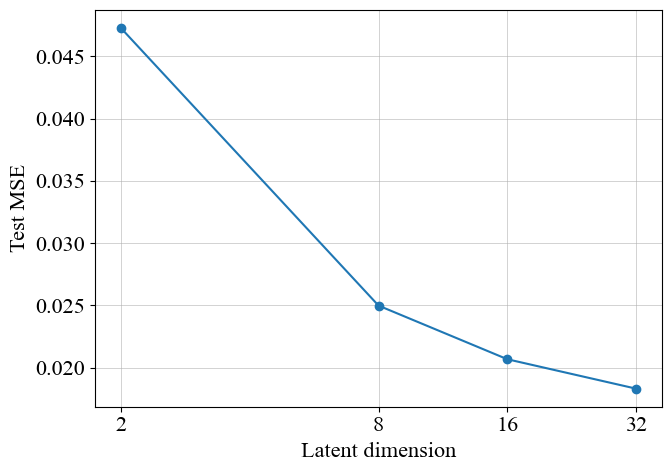

[saved] plot_latdim_recon_grid.pdf  (129.5 KB)  <- EPS was 37514.0 KB, used PDF


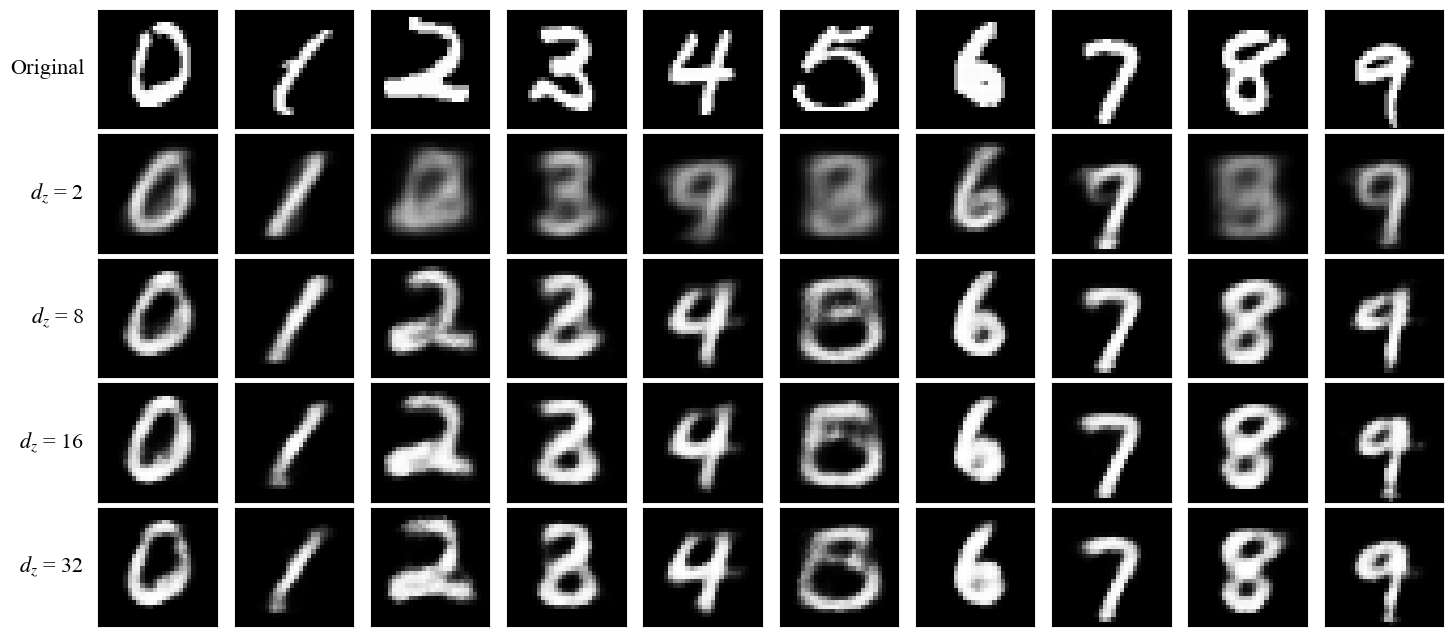

PosixPath('/content/outputs/plots/plot_latdim_recon_grid.pdf')

In [8]:
# ============================================================
# Cell 7: Latent-dimension study, FC-AE, dz in {2, 8, 16, 32}
# ============================================================
LATDIM = {}
for dz in CFG["latent_dims"]:
    if dz == CFG["latent_dim"]:                       # reuse the baseline model
        mdl, h = MODELS["FC-AE"], HISTORIES["FC-AE"]
        HISTORIES[f"FC-AE-dz{dz}"] = h
    else:
        mdl = build_fc_ae(dz)
        h = train_ae(mdl, f"FC-AE-dz{dz}", x_tr, x_va, CFG["epochs"])
        MODELS[f"FC-AE-dz{dz}"] = mdl
    xh = predict(mdl, x_te); RECON[f"FC-AE-dz{dz}"] = xh
    LATDIM[dz] = {**evaluate_recon(x_te, xh), "Params": count_params(mdl), "Time": h["time"]}

df_lat = pd.DataFrame.from_dict(LATDIM, orient="index")[["MSE", "MAE", "SSIM", "Params", "Time"]]
df_lat.index.name = "Latent dim"
save_table(df_lat, "table_latent_dim_fcae")

# epoch-wise comparison (MSE / MAE / SSIM per epoch, one curve per dz)
plot_epochwise({rf"$d_z$ = {dz}": HISTORIES[f"FC-AE-dz{dz}"] for dz in CFG["latent_dims"]},
               "plot_latdim_epochwise")

# Plot 10 (final test MSE vs latent dimension)
fig, ax = plt.subplots(figsize=(7, 5))
dzs = list(LATDIM)
ax.plot(dzs, [LATDIM[d]["MSE"] for d in dzs], "o-", color="tab:blue")
ax.set_xscale("log", base=2); ax.set_xticks(dzs); ax.set_xticklabels(dzs)
ax.set_xlabel("Latent dimension"); ax.set_ylabel("Test MSE"); ax.grid(True, lw=0.4)
fig.tight_layout(); save_fig(fig, "plot_latdim_vs_mse")

# qualitative effect of dz
show_grid([("Original", x_te[SHOW_IDX])] +
          [(rf"$d_z$ = {dz}", RECON[f"FC-AE-dz{dz}"][SHOW_IDX]) for dz in CFG["latent_dims"]],
          "plot_latdim_recon_grid")

[trained] CAE: params=74,497  time=23.6s  final val_loss=0.0695
[table] table_fc_vs_cae


,MSE,MAE,SSIM,Params
Model,,,,
Fully Connected AE,0.020679,0.056510,0.762617,211040
Convolutional AE,0.002695,0.015512,0.973914,74497


[saved] plot3_fc_vs_cae_reconstruction.pdf  (76.6 KB)  <- EPS was 22776.1 KB, used PDF


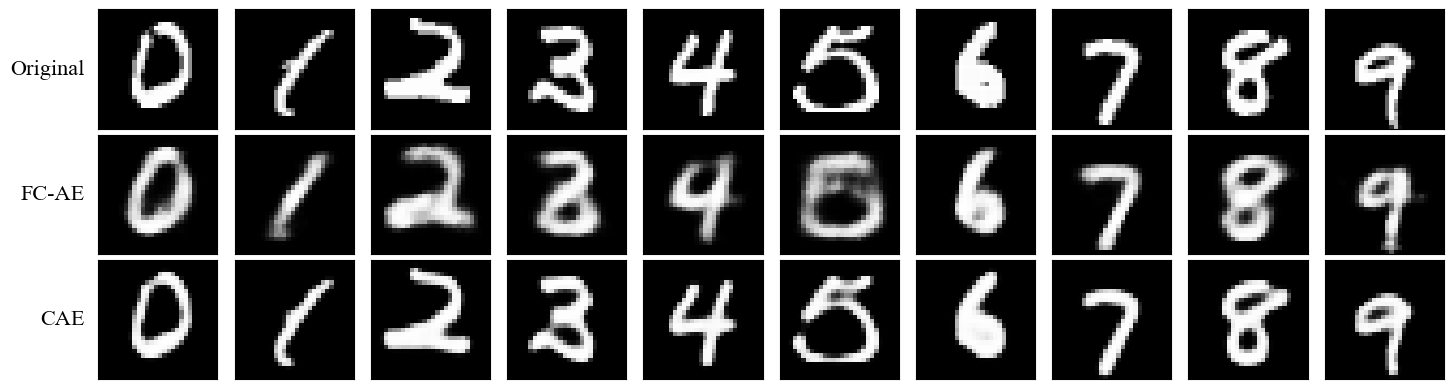

[saved] plot3b_fc_vs_cae_epochwise.pdf  (34.2 KB)  <- EPS was 123.2 KB, used PDF


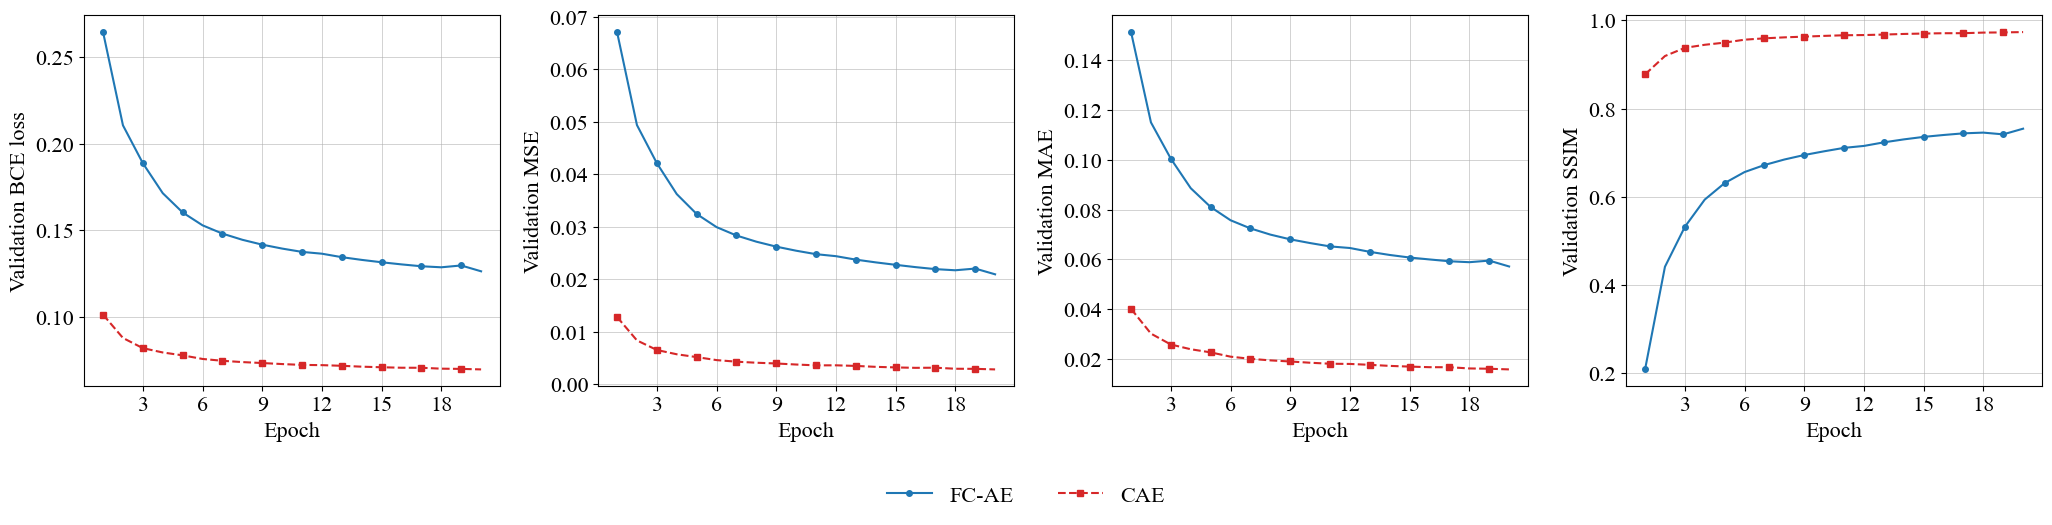

PosixPath('/content/outputs/plots/plot3b_fc_vs_cae_epochwise.pdf')

In [9]:
# ============================================================
# Cell 8: Convolutional AE + comparison with FC-AE
# ============================================================
cae = build_cae(None, "upsample", name="cae")
h_cae = train_ae(cae, "CAE", x_tr, x_va, CFG["cae_epochs"])
MODELS["CAE"] = cae

xh_cae = predict(cae, x_te); RECON["CAE"] = xh_cae
m_cae = evaluate_recon(x_te, xh_cae)
log_result("Conv. Autoencoder", **m_cae, Params=count_params(cae), Time=h_cae["time"])

cmp = pd.DataFrame.from_dict({
    "Fully Connected AE": {**m_fc, "Params": count_params(fc)},
    "Convolutional AE":   {**m_cae, "Params": count_params(cae)}}, orient="index")
cmp.index.name = "Model"
save_table(cmp, "table_fc_vs_cae")

# Plot 3: original -> FC-AE -> CAE
show_grid([("Original", x_te[SHOW_IDX]), ("FC-AE", xh_fc[SHOW_IDX]), ("CAE", xh_cae[SHOW_IDX])],
          "plot3_fc_vs_cae_reconstruction")

# epoch-wise comparison
plot_epochwise({"FC-AE": HISTORIES["FC-AE"], "CAE": HISTORIES["CAE"]},
               "plot3b_fc_vs_cae_epochwise",
               keys=[("val_loss", "Validation BCE loss")] + KEYS_METRIC, panel_w=5.2)

[trained] DCAE-gaussian: params=74,497  time=36.7s  final val_loss=0.0760


[table] table_denoising_gaussian


,MSE,MAE,SSIM,Input MSE,Input MAE,Input SSIM
Noise level,,,,,,
0.1,0.003628,0.017888,0.961265,0.005429,0.044128,0.697140
0.2,0.004548,0.021116,0.947300,0.021224,0.086707,0.613044
0.3,0.006920,0.029220,0.871357,0.046697,0.128168,0.528055


[saved] plot4_clean_noisy_denoised_gaussian.pdf  (84.9 KB)  <- EPS was 22778.9 KB, used PDF


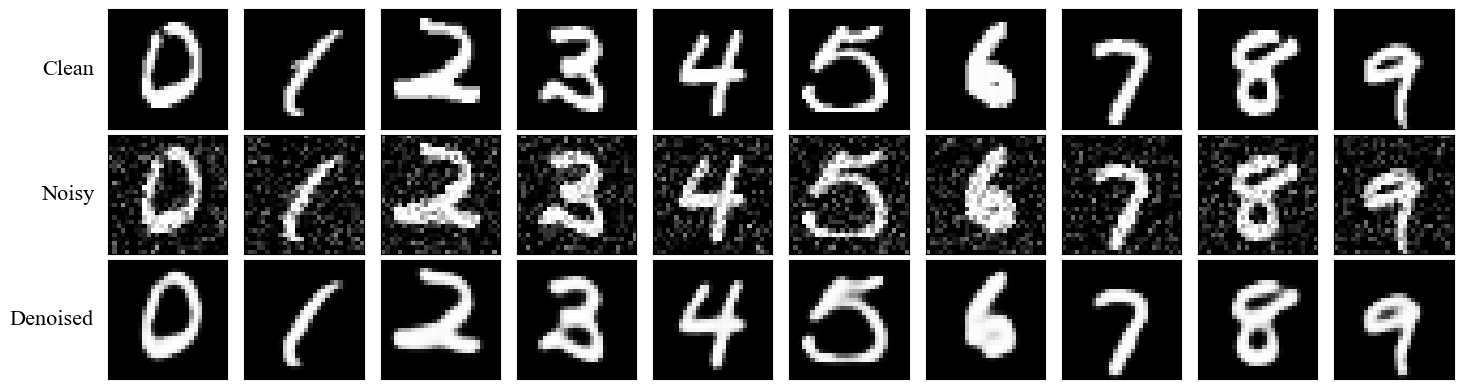

[saved] plot4b_all_levels_gaussian.pdf  (188.9 KB)  <- EPS was 52208.5 KB, used PDF


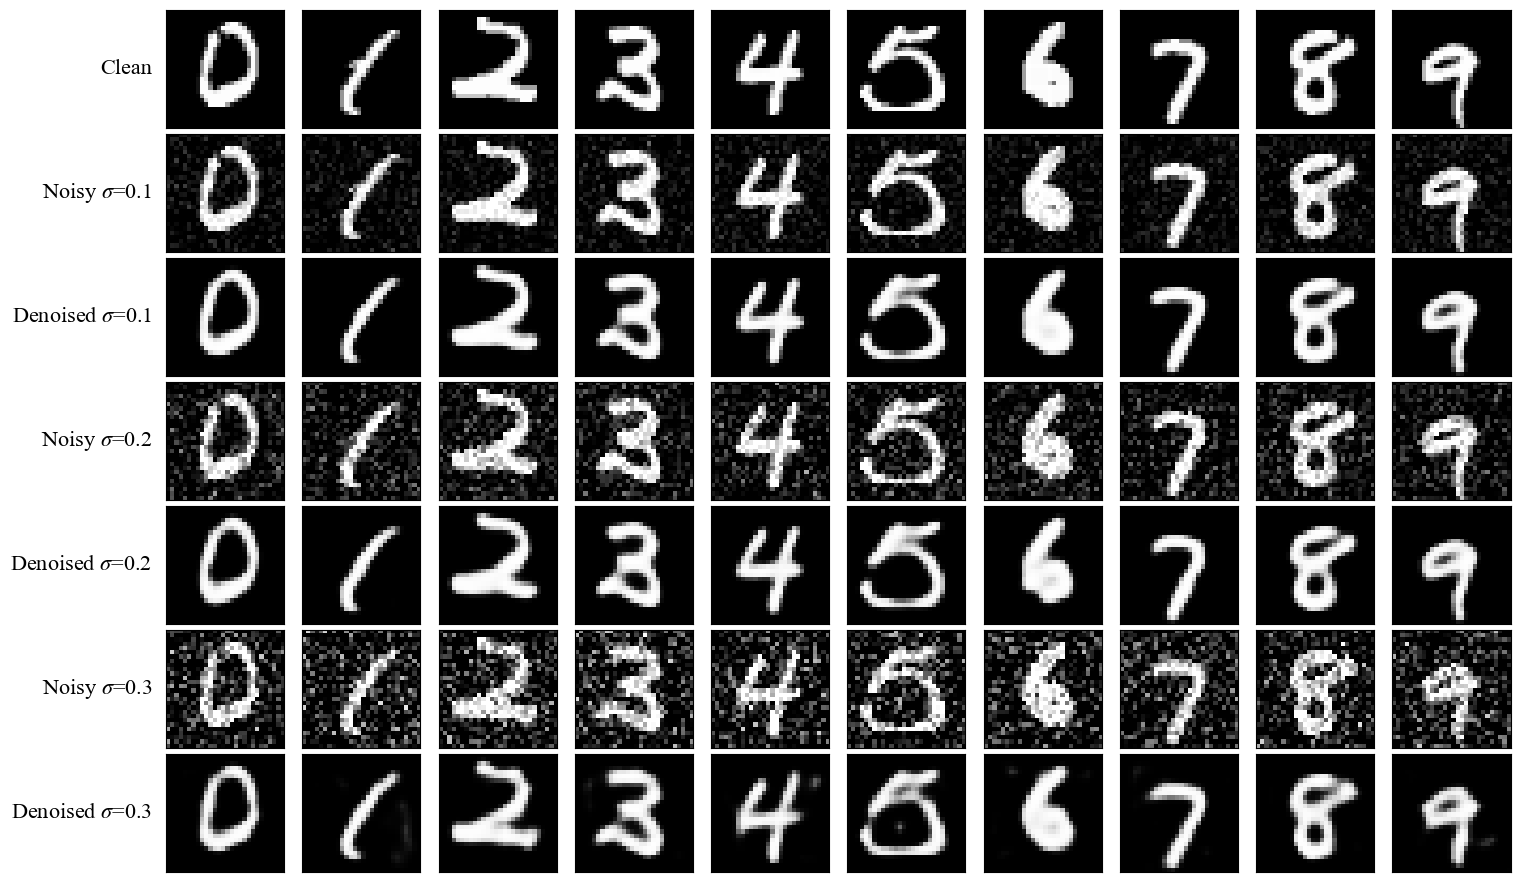

[saved] plot5_noise_vs_quality_gaussian.pdf  (32.6 KB)  <- EPS was 108.0 KB, used PDF


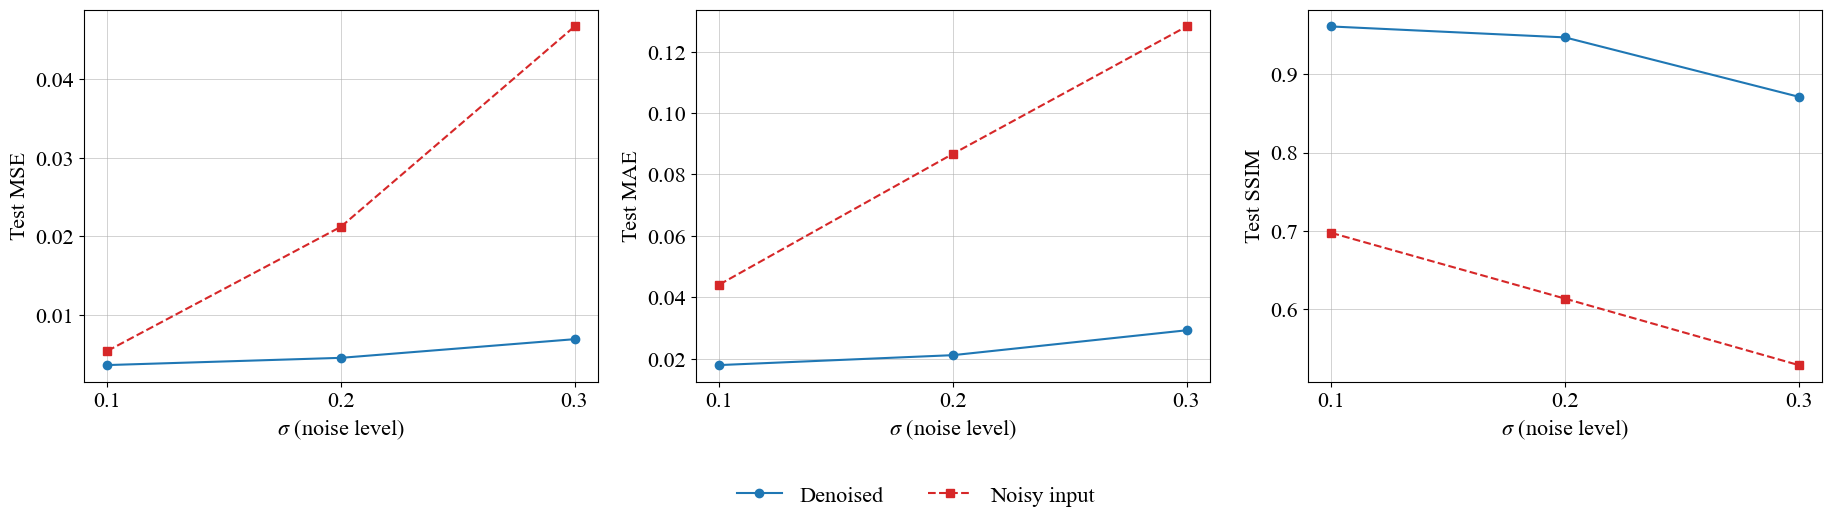

[saved] plot5b_noise_epochwise_gaussian.pdf  (33.5 KB)  <- EPS was 112.0 KB, used PDF


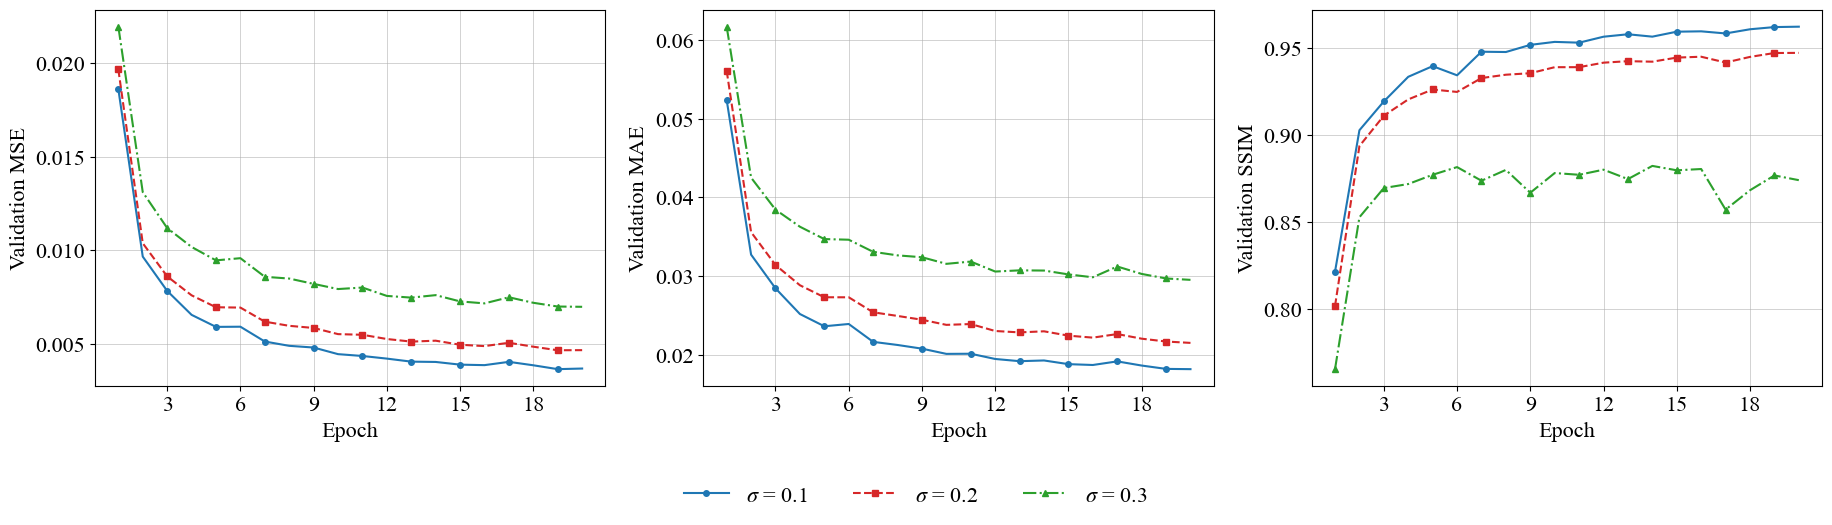

[trained] DCAE-sp: params=74,497  time=28.6s  final val_loss=0.0774
[table] table_denoising_sp


,MSE,MAE,SSIM,Input MSE,Input MAE,Input SSIM
Noise level,,,,,,
0.05,0.004107,0.019506,0.957056,0.023901,0.024830,0.724890
0.10,0.005048,0.021998,0.944576,0.047993,0.049853,0.595084
0.20,0.008302,0.030151,0.889336,0.096125,0.099846,0.463718


[saved] plot4_clean_noisy_denoised_sp.pdf  (76.2 KB)  <- EPS was 22778.9 KB, used PDF


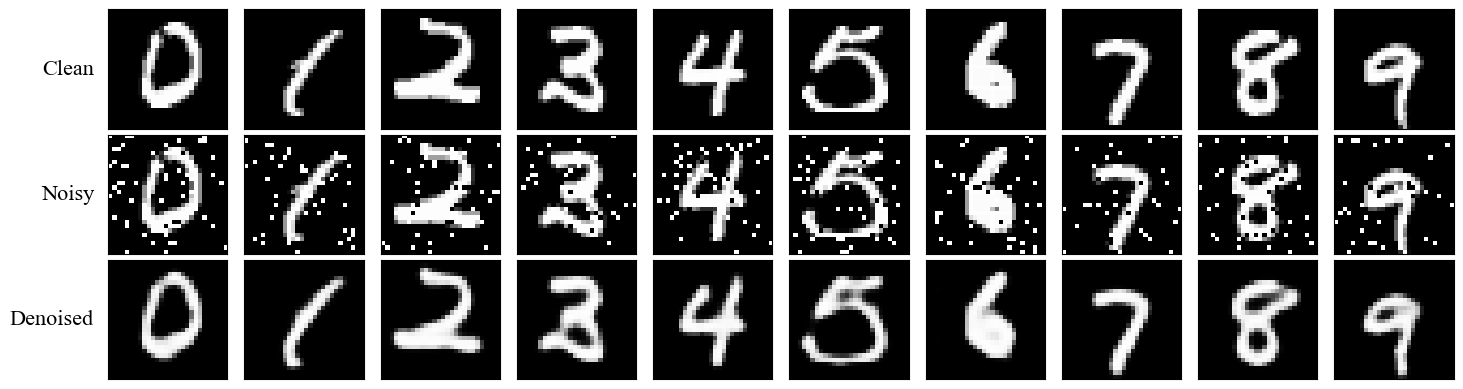

[saved] plot4b_all_levels_sp.pdf  (163.5 KB)  <- EPS was 52208.3 KB, used PDF


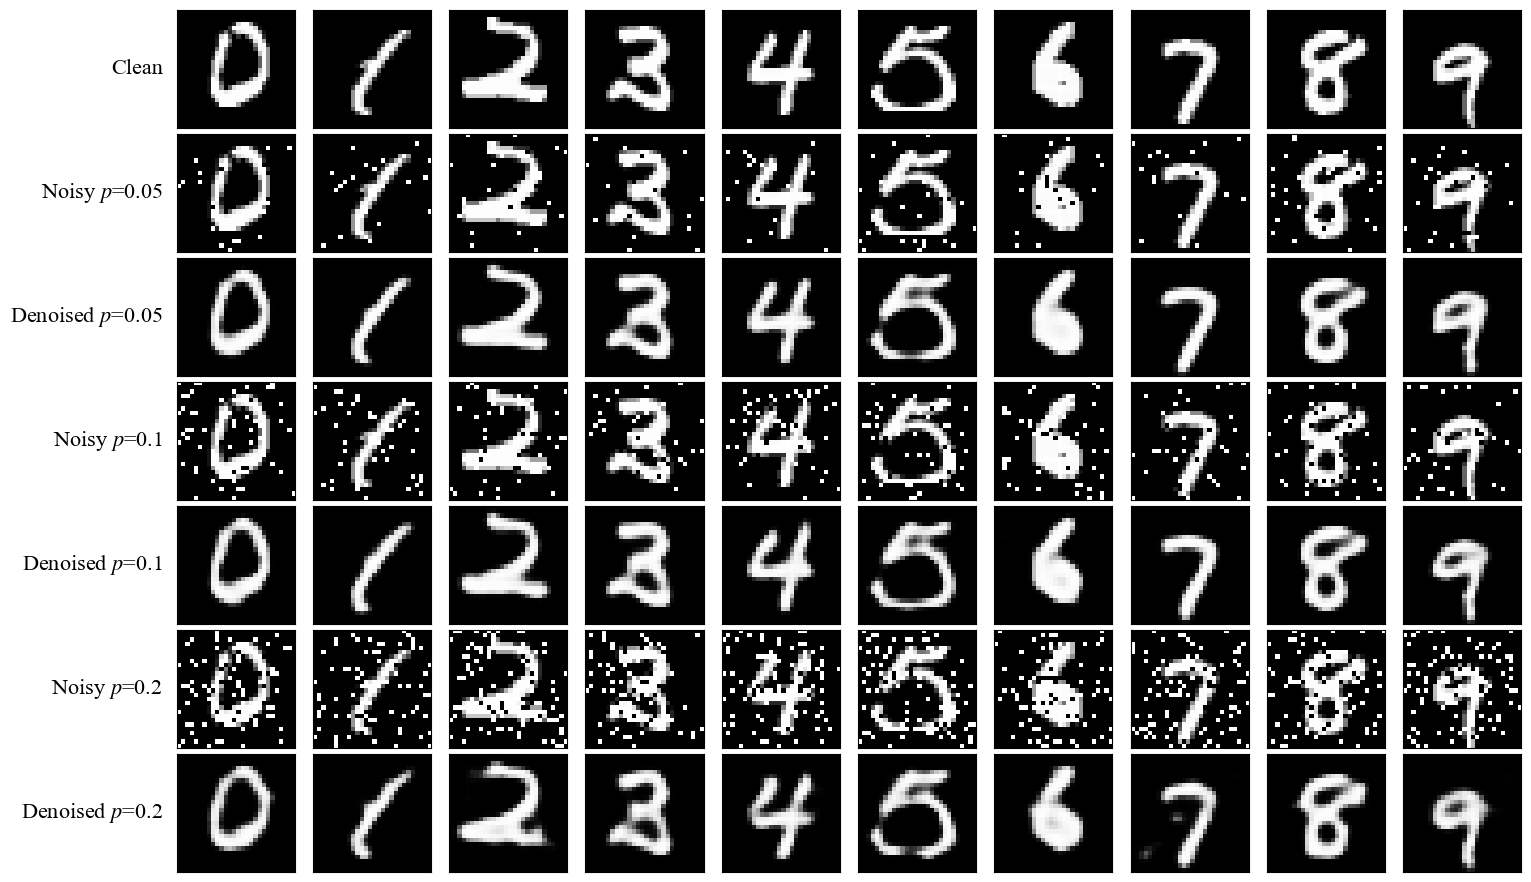

[saved] plot5_noise_vs_quality_sp.pdf  (32.7 KB)  <- EPS was 109.2 KB, used PDF


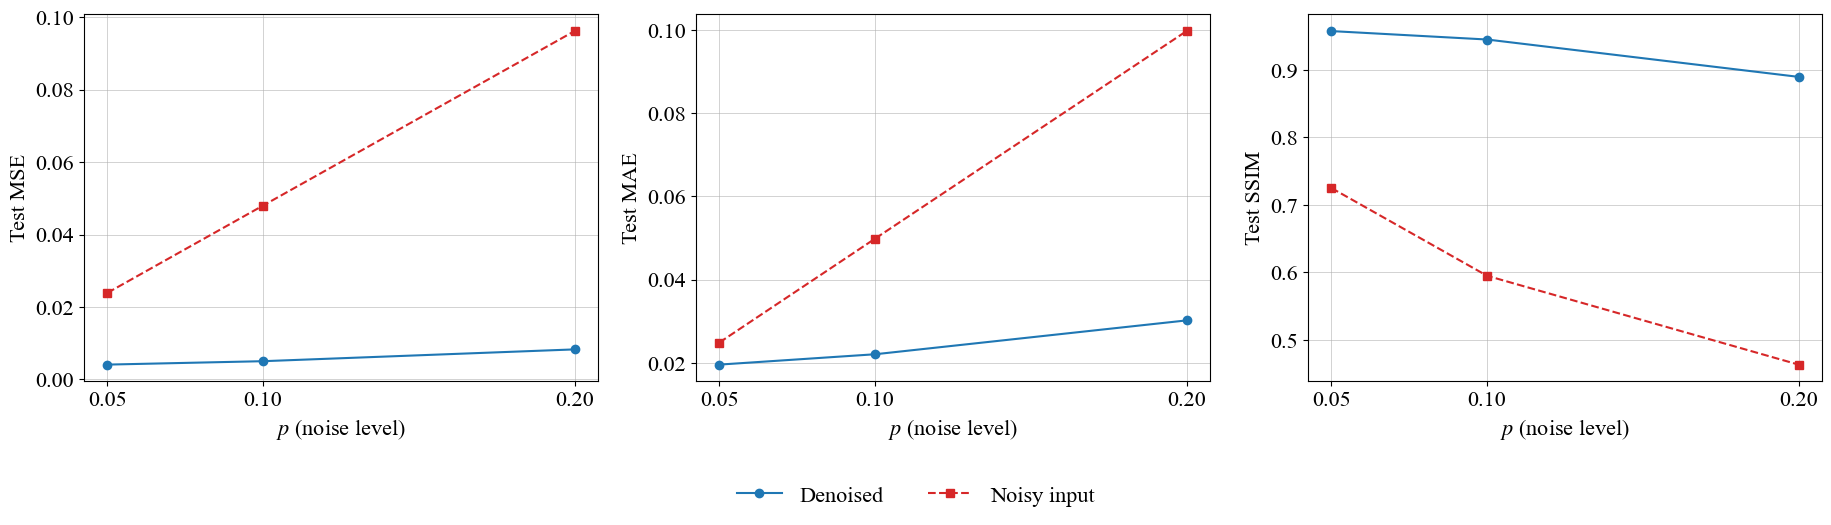

[saved] plot5b_noise_epochwise_sp.pdf  (33.9 KB)  <- EPS was 115.1 KB, used PDF


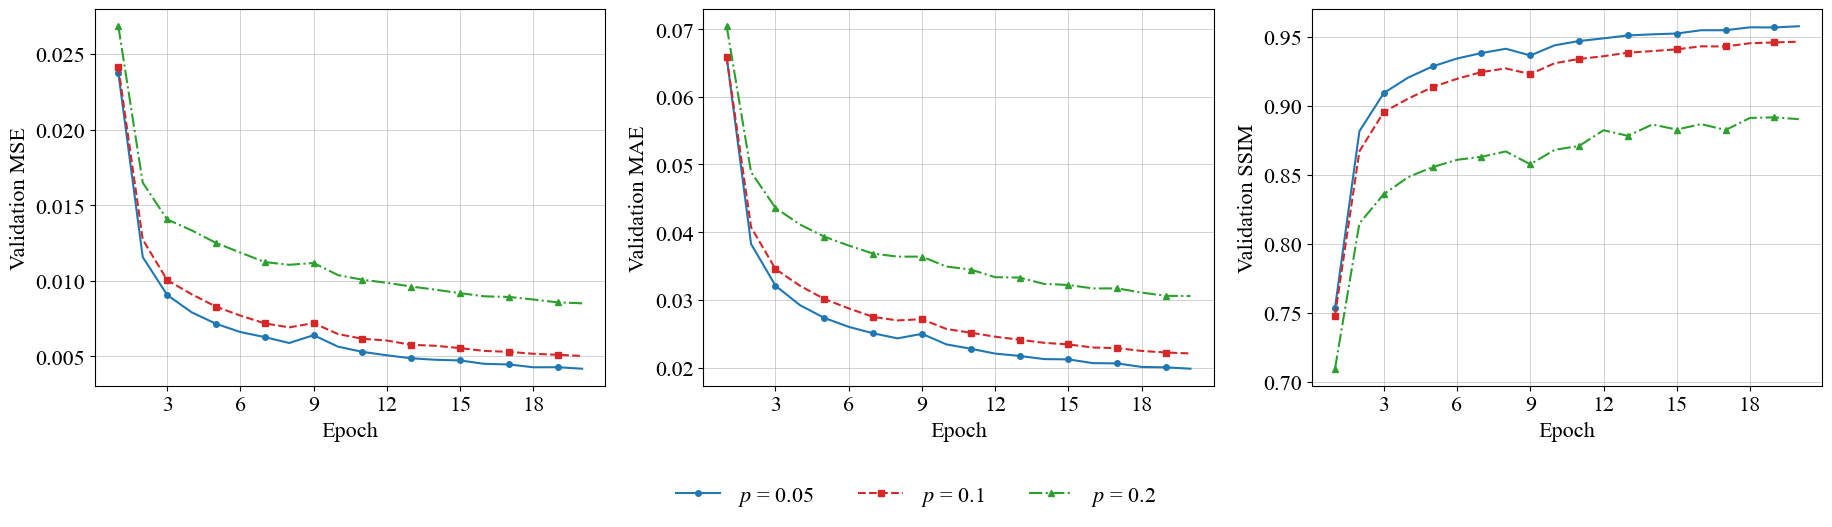

In [10]:
# ============================================================
# Cell 9: Denoising CAE - Gaussian and salt-and-pepper
# ============================================================
DAE = {}
for kind in ("gaussian", "sp"):
    dae = build_cae(None, "upsample", name=f"dcae_{kind}")
    h = train_ae(dae, f"DCAE-{kind}", x_tr, x_va, CFG["dae_epochs"],
                 noise=(kind, MAIN_NOISE[kind]), extra_eval=make_eval_sets(x_va, kind))
    MODELS[f"DCAE-{kind}"] = dae

    rows = []
    for i, lvl in enumerate(NOISE[kind]):
        xn = corrupt_np(x_te, kind, lvl, seed=TEST_SEED + i)
        xd = predict(dae, xn)
        md, mn = evaluate_recon(x_te, xd), evaluate_recon(x_te, xn)
        rows.append({"Noise level": lvl, **md, **{f"Input {k}": v for k, v in mn.items()}})
        if lvl == MAIN_NOISE[kind]:
            RECON[f"DCAE-{kind}"] = xd
            DAE[kind] = {"noisy": xn, "den": xd}
    tab = pd.DataFrame(rows).set_index("Noise level")
    DAE[kind]["table"] = tab
    save_table(tab, f"table_denoising_{kind}")

    # Plot 4: clean / noisy / denoised at the training noise level
    show_grid([("Clean", x_te[SHOW_IDX]), ("Noisy", DAE[kind]["noisy"][SHOW_IDX]),
               ("Denoised", DAE[kind]["den"][SHOW_IDX])],
              f"plot4_clean_noisy_denoised_{kind}")

    # Plot 4b: all three noise levels
    rows_g = [("Clean", x_te[SHOW_IDX])]
    sym = r"$\sigma$" if kind == "gaussian" else r"$p$"
    for i, lvl in enumerate(NOISE[kind]):
        xn = corrupt_np(x_te, kind, lvl, seed=TEST_SEED + i)
        rows_g += [(f"Noisy {sym}={lvl}", xn[SHOW_IDX]),
                   (f"Denoised {sym}={lvl}", predict(dae, xn[SHOW_IDX]))]
    show_grid(rows_g, f"plot4b_all_levels_{kind}")

    # Plot 5 (final values): noise level vs quality, denoised output vs raw noisy input
    fig, axes = plt.subplots(1, 3, figsize=(18.6, 4.8))
    for ax, met in zip(axes, ("MSE", "MAE", "SSIM")):
        ax.plot(tab.index, tab[met], "o-", color="tab:blue", label="Denoised")
        ax.plot(tab.index, tab[f"Input {met}"], "s--", color="tab:red", label="Noisy input")
        ax.set_xticks(tab.index); ax.set_xlabel(sym + " (noise level)"); ax.set_ylabel(f"Test {met}")
        ax.grid(True, lw=0.4)
    fig.tight_layout(); _legend_below(fig, axes[0], 2)
    save_fig(fig, f"plot5_noise_vs_quality_{kind}")

    # Plot 5b (epoch-wise): validation metrics per epoch at each noise level
    lab = (lambda l: rf"$\sigma$ = {l}") if kind == "gaussian" else (lambda l: rf"$p$ = {l}")
    plot_epochwise({lab(l): eval_to_hist(h["eval"][str(l)]) for l in NOISE[kind]},
                   f"plot5b_noise_epochwise_{kind}")

# Consolidated-table entry: Gaussian sigma = 0.2 denoiser, scored against the clean image
row = DAE["gaussian"]["table"].loc[MAIN_NOISE["gaussian"]]
log_result("Denoising CAE", MSE=row["MSE"], MAE=row["MAE"], SSIM=row["SSIM"],
           Params=count_params(MODELS["DCAE-gaussian"]), Time=HISTORIES["DCAE-gaussian"]["time"])

[trained] VAE: params=485,957  time=39.8s  final val_loss=154.80
{'Rec loss': 147.3004, 'KL loss': 6.2092, 'Total loss': 153.5096, 'MSE': 0.0422, 'MAE': 0.098, 'SSIM': 0.5363}
[saved] plot9_vae_train_val_loss.pdf  (31.9 KB)  <- EPS was 118.1 KB, used PDF


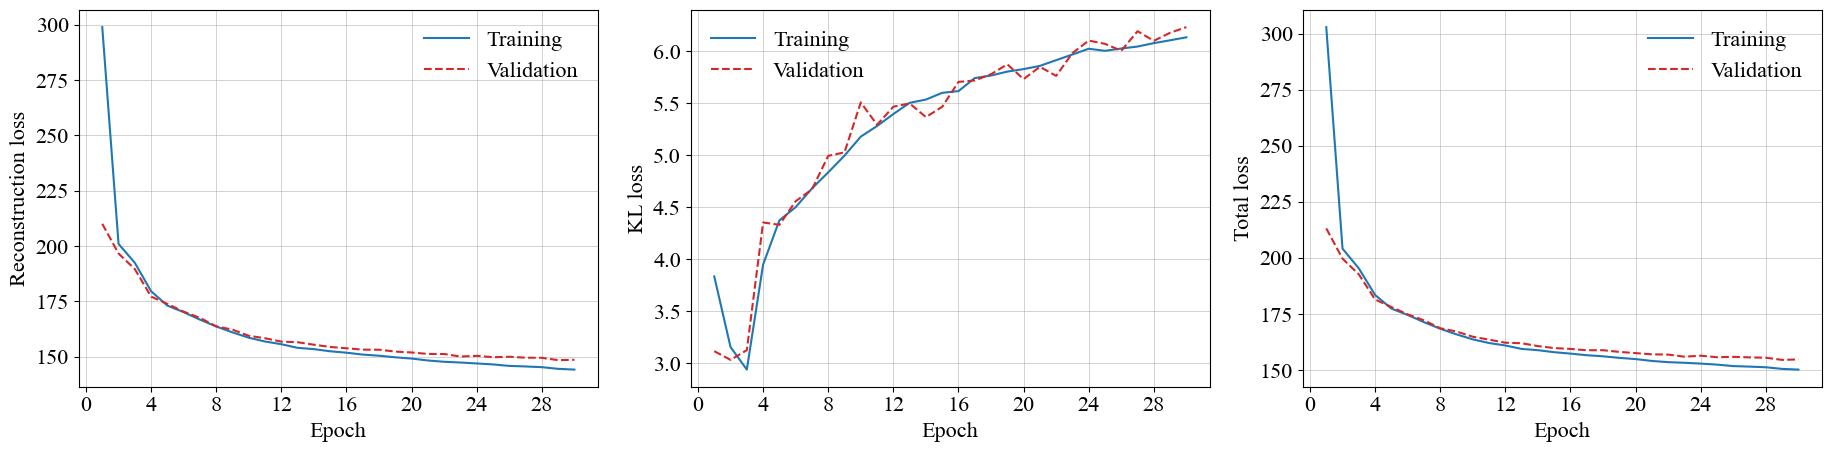

[saved] plot6_vae_latent_space.pdf  (59.6 KB)  <- EPS was 118.8 KB, used PDF


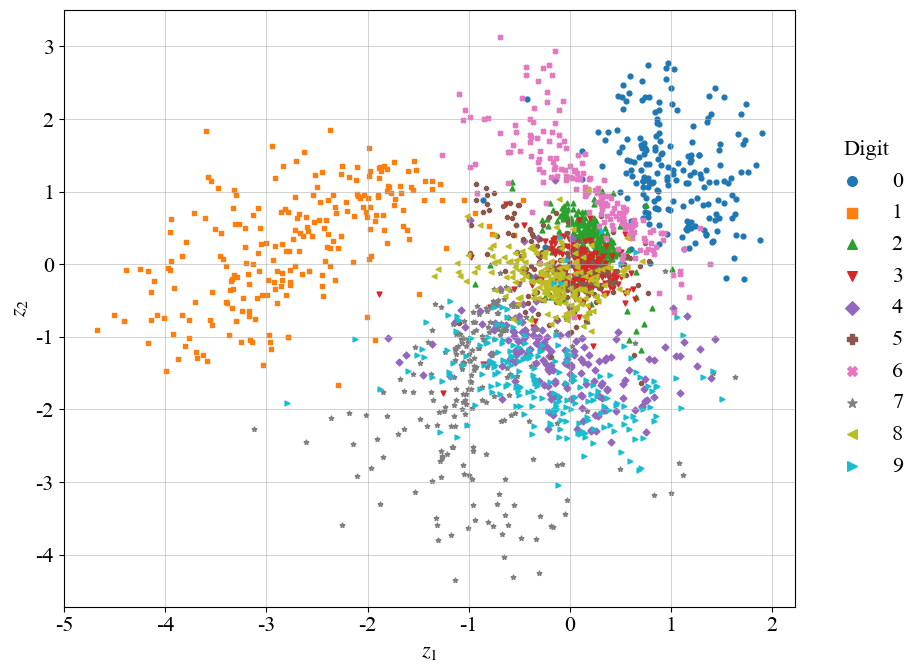

[table] table_vae_latent_stats


,mean(mu),std(mu),mean(sigma),Aggregate std,KL per dim
z1,-0.326793,1.10229,0.054441,1.104044,3.182627
z2,-0.228746,1.16723,0.063655,1.169194,3.026620


[saved] plot_vae_latent_marginals.pdf  (35.0 KB)  <- EPS was 112.4 KB, used PDF


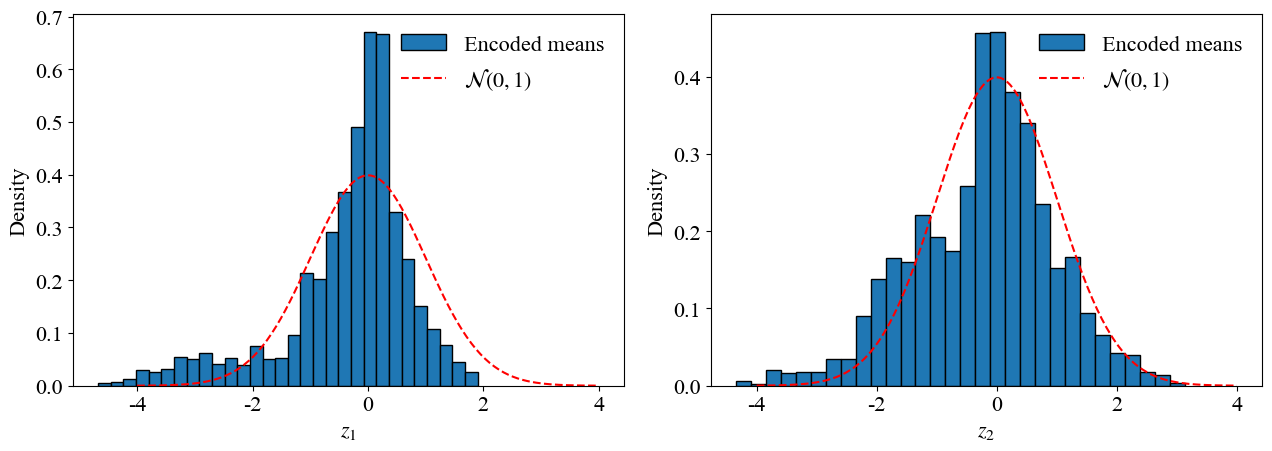

[saved] plot7_vae_generated.pdf  (30.8 KB)  <- EPS was 9540.3 KB, used PDF


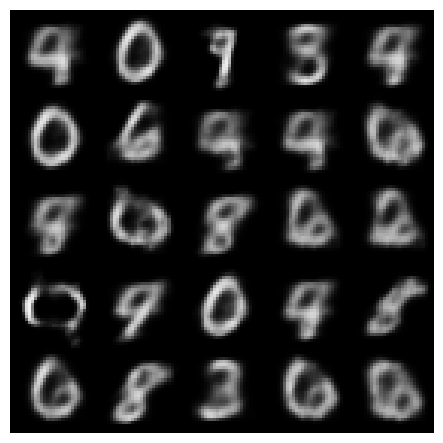

[saved] plot8_vae_interpolation.pdf  (45.8 KB)  <- EPS was 8673.4 KB, used PDF


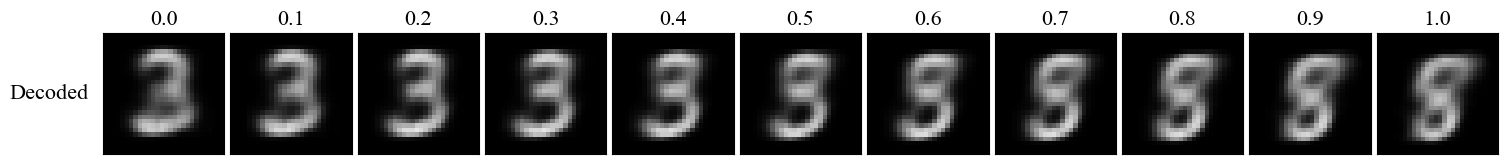

PosixPath('/content/outputs/plots/plot8_vae_interpolation.pdf')

In [11]:
# ============================================================
# Cell 10: VAE (dz = 2)
# ============================================================
DZ = CFG["vae_latent_dim"]
vae, h_vae = train_vae(DZ, 1.0, "VAE")
MODELS["VAE"] = vae

m_vae, xh_vae = evaluate_vae(vae, x_te); RECON["VAE"] = xh_vae
log_result("VAE", **m_vae, Params=count_vae_params(vae), Time=h_vae["time"])
print({k: round(v, 4) for k, v in m_vae.items()})

# Plot 9: training / validation loss (reconstruction, KL, total)
plot_train_val(h_vae, [("rec_loss", "Reconstruction loss"), ("kl_loss", "KL loss"),
                       ("loss", "Total loss")], "plot9_vae_train_val_loss")

# Encode test set
MU_TE, LV_TE, _ = [np.asarray(a) for a in vae.encoder.predict(x_te, batch_size=256, verbose=0)]

# Plot 6: latent space
fig, ax = plt.subplots(figsize=(9.5, 7))
scatter_latent(ax, MU_TE, y_te)
ax.set_xlabel(r"$z_1$"); ax.set_ylabel(r"$z_2$"); ax.grid(True, lw=0.4)
ax.legend(title="Digit", loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2)
fig.tight_layout(); save_fig(fig, "plot6_vae_latent_space")

# Latent statistics (numbers for the latent-distribution inference)
kl_dim = -0.5 * np.mean(1 + LV_TE - MU_TE ** 2 - np.exp(LV_TE), axis=0)
stats = pd.DataFrame({"mean(mu)": MU_TE.mean(0), "std(mu)": MU_TE.std(0),
                      "mean(sigma)": np.exp(0.5 * LV_TE).mean(0),
                      "Aggregate std": np.sqrt(MU_TE.var(0) + np.exp(LV_TE).mean(0)),
                      "KL per dim": kl_dim}, index=[f"z{j+1}" for j in range(DZ)])
save_table(stats, "table_vae_latent_stats")

# Latent marginals vs N(0,1)
fig, axes = plt.subplots(1, DZ, figsize=(6.5 * DZ, 4.8), squeeze=False)
xs = np.linspace(-4, 4, 200)
for j, ax in enumerate(axes[0]):
    ax.hist(MU_TE[:, j], bins=30, density=True, color="tab:blue", edgecolor="black", lw=0.4,
            label="Encoded means")
    ax.plot(xs, norm.pdf(xs), "r--", label=r"$\mathcal{N}(0,1)$")
    ax.set_xlabel(rf"$z_{j+1}$"); ax.set_ylabel("Density"); ax.legend()
fig.tight_layout(); save_fig(fig, "plot_vae_latent_marginals")

# Plot 7: 25 random samples z ~ N(0, I)
Z_GEN = np.random.default_rng(SEED).standard_normal((CFG["n_generated"], DZ)).astype("float32")
gen = np.asarray(vae.decoder.predict(Z_GEN, verbose=0))
gallery(gen, 5, 5, "plot7_vae_generated", cell=1.1)

# Plot 8: latent interpolation between the encodings of two test digits
def interpolate(decoder, zA, zB, alphas):
    z = np.stack([(1 - a) * zA + a * zB for a in alphas]).astype("float32")
    return np.asarray(decoder.predict(z, verbose=0))

INTERP_DIGITS = (3, 8)
zA = MU_TE[np.where(y_te == INTERP_DIGITS[0])[0][0]]
zB = MU_TE[np.where(y_te == INTERP_DIGITS[1])[0][0]]
alphas = CFG["interp_alphas"]
show_grid([("Decoded", interpolate(vae.decoder, zA, zB, alphas))], "plot8_vae_interpolation",
          col_titles=[f"{a:.1f}" for a in alphas], cell=1.5)

[saved] plot10_reconstruction_error_distribution.pdf  (33.2 KB)  <- EPS was 129.7 KB, used PDF


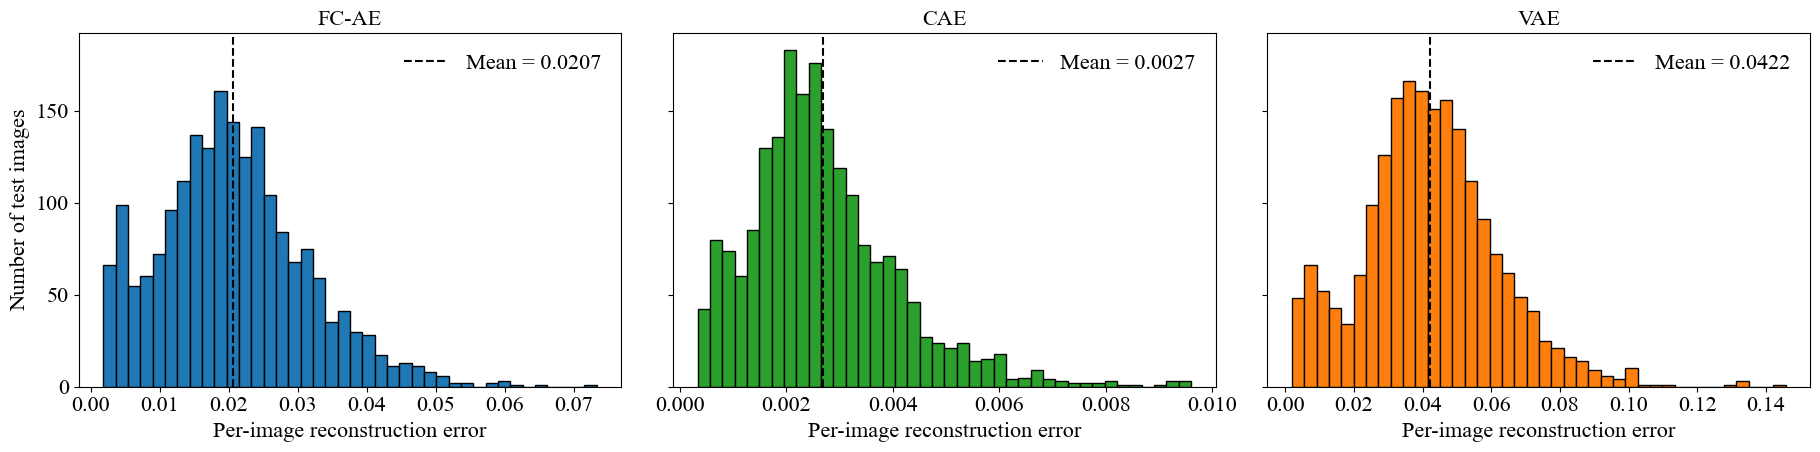

[table] table_error_distribution


,Mean,Median,Std,P95,Max
Model,,,,,
FC-AE,0.020679,0.019873,0.010622,0.039595,0.073269
CAE,0.002695,0.002489,0.001395,0.005331,0.009598
VAE,0.042174,0.041138,0.019700,0.075032,0.145715


[saved] high_error_fcae.pdf  (67.1 KB)  <- EPS was 20238.5 KB, used PDF


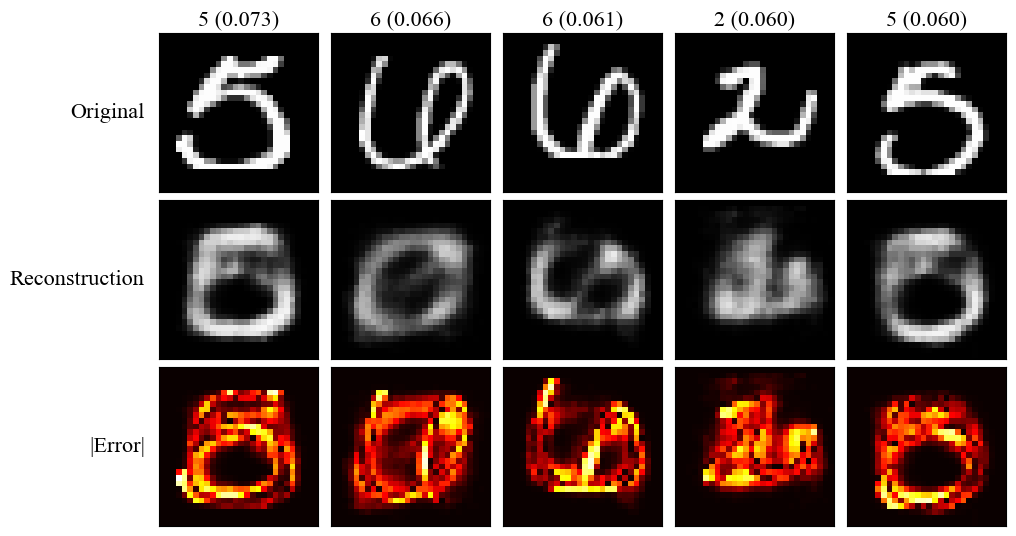

[table] table_high_error_fcae


,Test index,Digit,MSE
Sample,,,
1,9,5,0.073269
2,660,6,0.065876
3,327,6,0.061455
4,1903,2,0.060457
5,115,5,0.060176


[saved] high_error_cae.pdf  (64.7 KB)  <- EPS was 20236.1 KB, used PDF


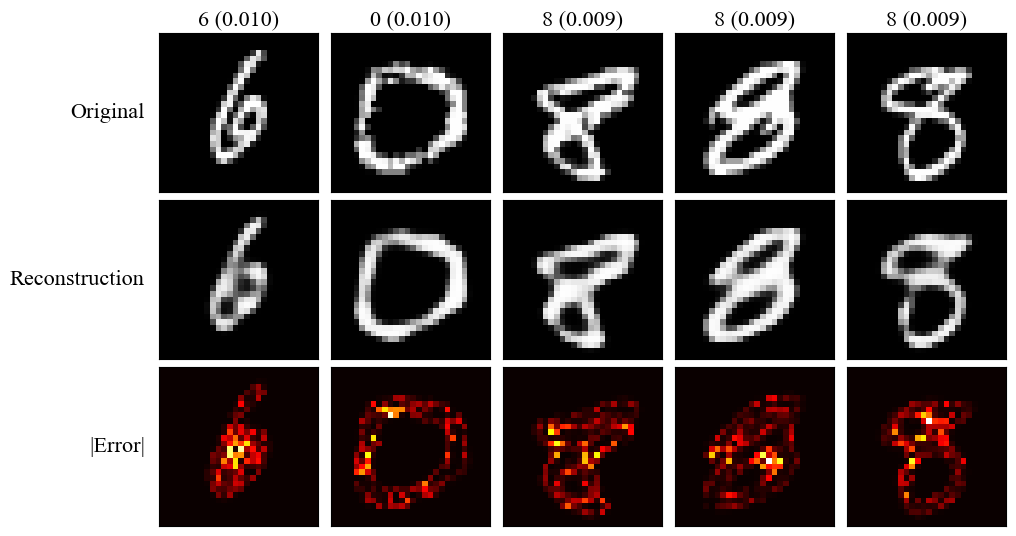

[table] table_high_error_cae


,Test index,Digit,MSE
Sample,,,
1,892,6,0.009598
2,1317,0,0.009525
3,152,8,0.009373
4,682,8,0.009303
5,1980,8,0.009288


[saved] error_vs_visual_quality_fcae.pdf  (50.2 KB)  <- EPS was 14374.6 KB, used PDF


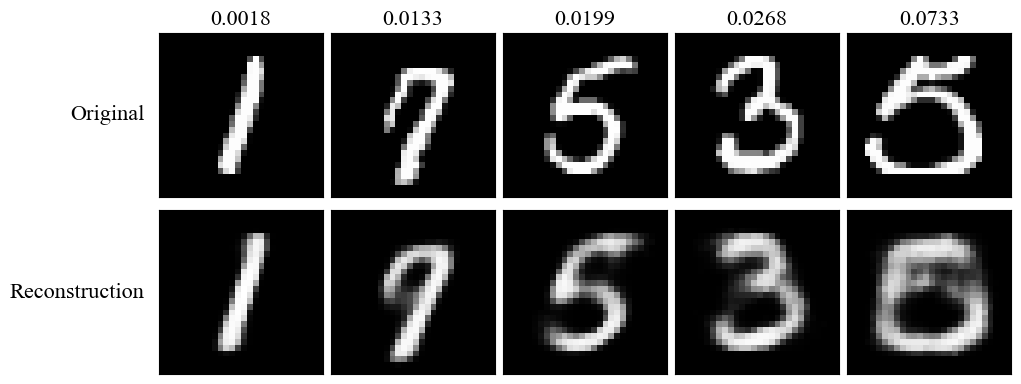

PosixPath('/content/outputs/plots/error_vs_visual_quality_fcae.pdf')

In [12]:
# ============================================================
# Cell 11: Reconstruction-error distribution + high-error images
# ============================================================
ERR_MODELS = {"FC-AE": "FC-AE", "CAE": "CAE", "VAE": "VAE"}
errs = {n: per_image_mse(x_te, RECON[k]) for n, k in ERR_MODELS.items()}

fig, axes = plt.subplots(1, 3, figsize=(18.6, 4.8), sharey=True)
for ax, (n, e), c in zip(axes, errs.items(), ("tab:blue", "tab:green", "tab:orange")):
    ax.hist(e, bins=40, color=c, edgecolor="black", lw=0.4)
    ax.axvline(e.mean(), color="k", ls="--", label=f"Mean = {e.mean():.4f}")
    ax.set_xlabel("Per-image reconstruction error"); ax.set_title(n); ax.legend()
axes[0].set_ylabel("Number of test images")
fig.tight_layout(); save_fig(fig, "plot10_reconstruction_error_distribution")

desc = pd.DataFrame({n: {"Mean": e.mean(), "Median": np.median(e), "Std": e.std(),
                         "P95": np.percentile(e, 95), "Max": e.max()}
                     for n, e in errs.items()}).T
desc.index.name = "Model"
save_table(desc, "table_error_distribution", "%.5f")

# Five worst test images
def high_error_analysis(tag, xh, k=5):
    e = per_image_mse(x_te, xh)
    idx = np.argsort(e)[::-1][:k]
    show_grid([("Original", x_te[idx]), ("Reconstruction", xh[idx]),
               err_row("|Error|", x_te[idx], xh[idx])],
              f"high_error_{tag}", col_titles=[f"{y_te[i]} ({e[i]:.3f})" for i in idx], cell=1.9)
    t = pd.DataFrame({"Test index": idx, "Digit": y_te[idx], "MSE": e[idx]},
                     index=pd.RangeIndex(1, k + 1, name="Sample"))
    save_table(t, f"table_high_error_{tag}", "%.5f")

high_error_analysis("fcae", RECON["FC-AE"])
high_error_analysis("cae", RECON["CAE"])

# Error vs visual quality: FC-AE images at the 0/25/50/75/100th error percentiles
e = errs["FC-AE"]; order = np.argsort(e)
pick = order[[int(q * (len(e) - 1)) for q in (0, 0.25, 0.5, 0.75, 1.0)]]
show_grid([("Original", x_te[pick]), ("Reconstruction", RECON["FC-AE"][pick])],
          "error_vs_visual_quality_fcae", col_titles=[f"{e[i]:.4f}" for i in pick], cell=1.9)

[table] table_consolidated


,MSE,MAE,SSIM,Params,Time
Model,,,,,
FC Autoencoder,0.020679,0.056510,0.762617,211040,14.781381
Conv. Autoencoder,0.002695,0.015512,0.973914,74497,23.567069
Denoising CAE,0.004548,0.021116,0.947300,74497,36.741071
VAE,0.042174,0.098037,0.536250,485957,39.758388


[table] table_reconstruction_models


,MSE,MAE,SSIM,Params
Model,,,,
FC Autoencoder,0.020679,0.056510,0.762617,211040
Conv. Autoencoder,0.002695,0.015512,0.973914,74497
Denoising CAE,0.004548,0.021116,0.947300,74497


[table] table_vae_metrics


,Value
Reconstruction Loss,147.300369
KL Loss,6.209250
Total Loss,153.509644
Test MSE,0.042174
Test MAE,0.098037
Mean SSIM,0.536250


[saved] plot_all_models_epochwise.pdf  (39.9 KB)  <- EPS was 134.5 KB, used PDF


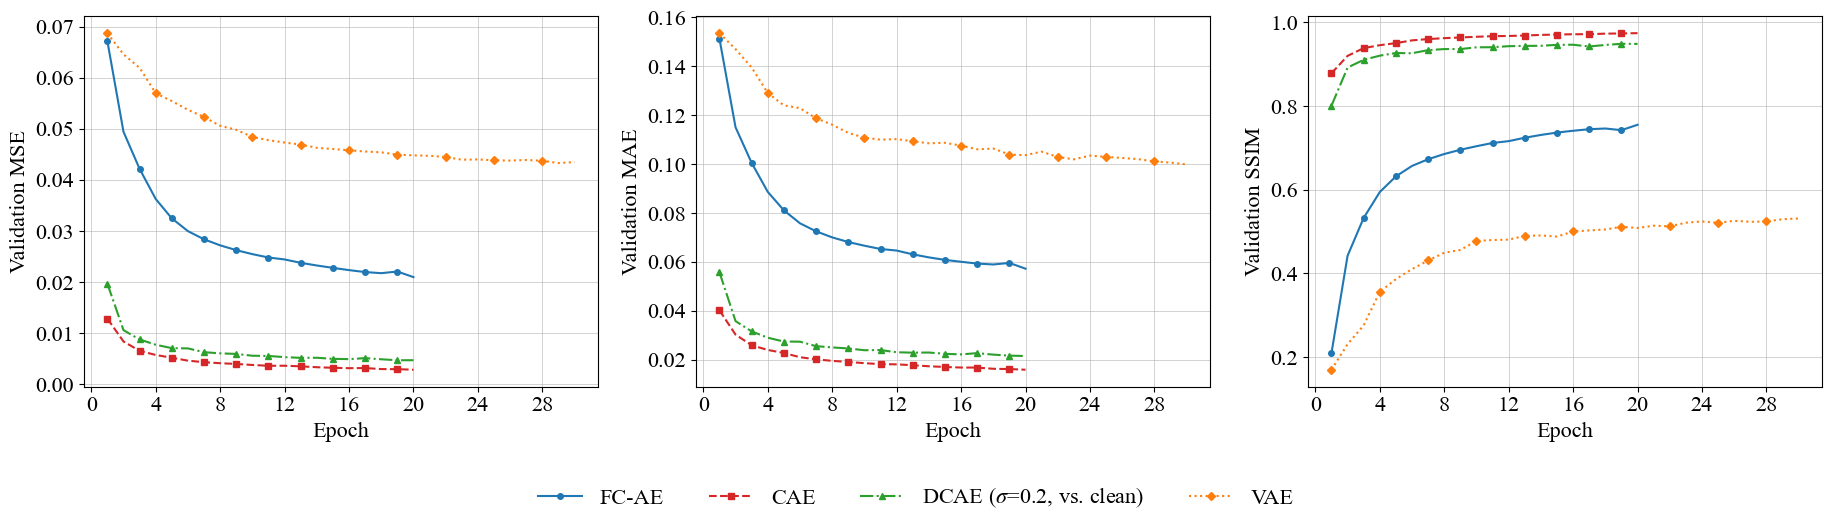

PosixPath('/content/outputs/plots/plot_all_models_epochwise.pdf')

In [13]:
# ============================================================
# Cell 12: Consolidated tables + all-model epoch-wise comparison
# ============================================================
order = ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"]
cons = pd.DataFrame.from_dict({k: RESULTS[k] for k in order}, orient="index")
cons = cons[["MSE", "MAE", "SSIM", "Params", "Time"]]; cons.index.name = "Model"
save_table(cons, "table_consolidated")                                   # Section 25
save_table(cons.loc[order[:3], ["MSE", "MAE", "SSIM", "Params"]], "table_reconstruction_models")  # Section 21

v = RESULTS["VAE"]
vt = pd.DataFrame({"Value": [v["Rec loss"], v["KL loss"], v["Total loss"], v["MSE"], v["MAE"], v["SSIM"]]},
                  index=["Reconstruction Loss", "KL Loss", "Total Loss", "Test MSE", "Test MAE", "Mean SSIM"])
save_table(vt, "table_vae_metrics")

plot_epochwise({"FC-AE": HISTORIES["FC-AE"], "CAE": HISTORIES["CAE"],
                r"DCAE ($\sigma$=0.2, vs. clean)": HISTORIES["DCAE-gaussian"],
                "VAE": HISTORIES["VAE"]},
               "plot_all_models_epochwise", ncol=4)

[trained] CAE-dz4: params=65,797  time=24.0s  final val_loss=0.1620
[trained] CAE-dz8: params=90,889  time=22.2s  final val_loss=0.1244
[trained] CAE-dz16: params=141,073  time=22.1s  final val_loss=0.0947
[trained] CAE-dz32: params=241,441  time=23.2s  final val_loss=0.0827
[table] table_ex1_cae_latent_dim


,MSE,MAE,SSIM,Params,Time
Latent dim,,,,,
4,0.033233,0.080226,0.657415,65797,23.999400
8,0.020170,0.055053,0.779632,90889,22.226340
16,0.010426,0.033860,0.891000,141073,22.065545
32,0.006643,0.025257,0.930747,241441,23.194309


[saved] ex1_cae_latent_dim_epochwise.pdf  (40.2 KB)  <- EPS was 131.7 KB, used PDF


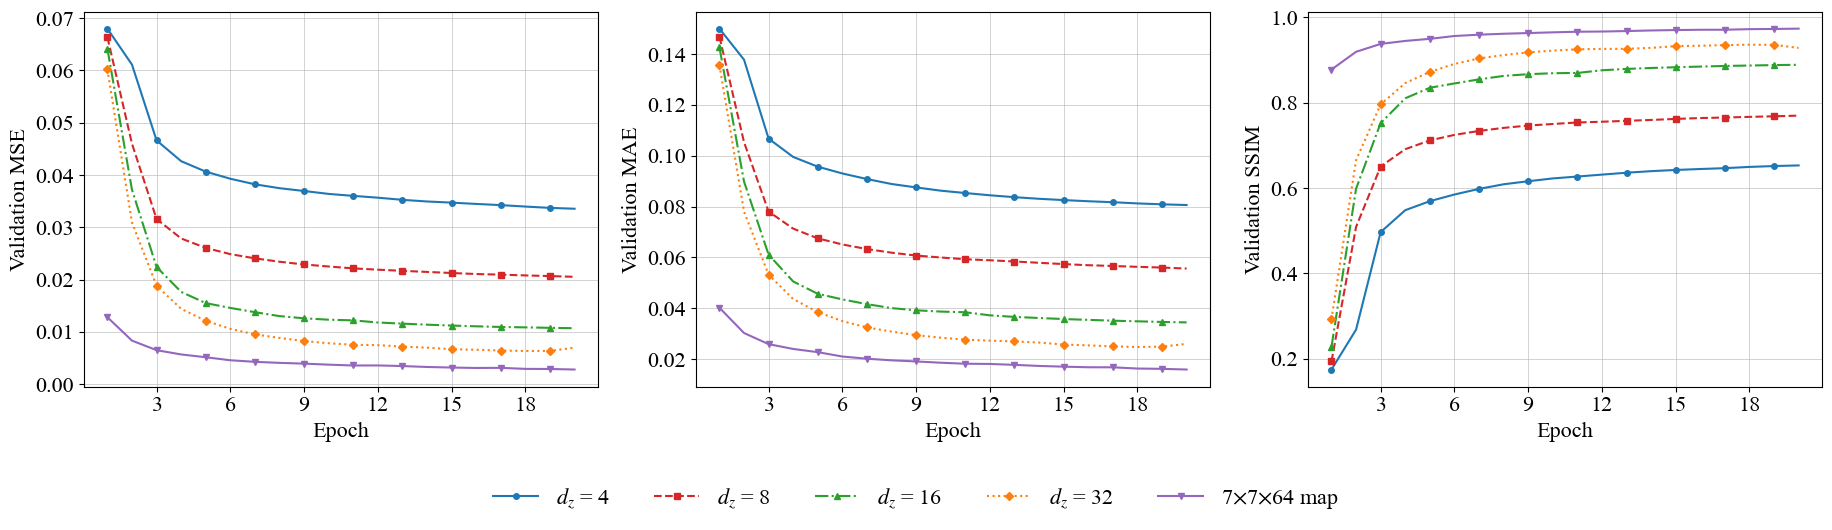

[saved] ex1_cae_latent_dim_recon_grid.pdf  (126.2 KB)  <- EPS was 37515.2 KB, used PDF


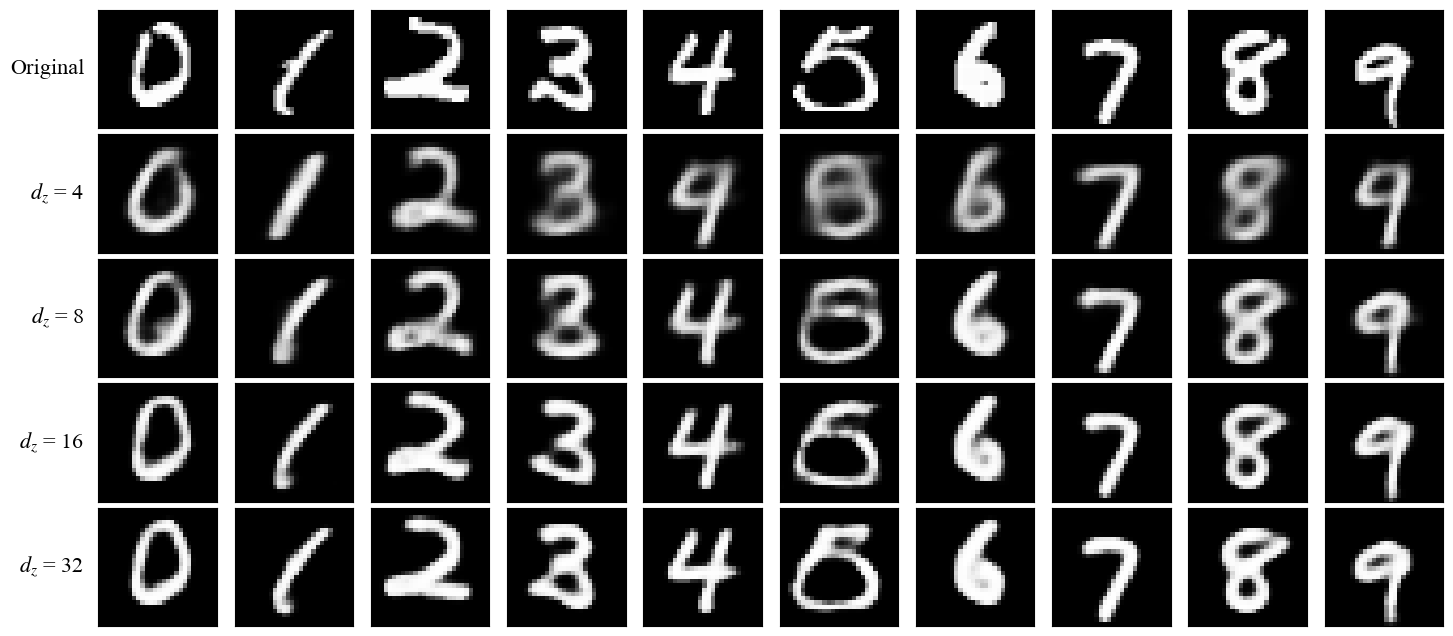

PosixPath('/content/outputs/plots/ex1_cae_latent_dim_recon_grid.pdf')

In [14]:
# ============================================================
# Cell 13: Exercise 1 - CAE with a dense bottleneck of size dz
# ============================================================
CAE_DZ = {}
for dz in CFG["cae_latent_dims"]:
    mdl = build_cae(dz, "upsample", name=f"cae_dz{dz}")
    h = train_ae(mdl, f"CAE-dz{dz}", x_tr, x_va, CFG["cae_epochs"])
    MODELS[f"CAE-dz{dz}"] = mdl
    xh = predict(mdl, x_te); RECON[f"CAE-dz{dz}"] = xh
    CAE_DZ[dz] = {**evaluate_recon(x_te, xh), "Params": count_params(mdl), "Time": h["time"]}

df = pd.DataFrame.from_dict(CAE_DZ, orient="index"); df.index.name = "Latent dim"
save_table(df, "table_ex1_cae_latent_dim")

hists = {rf"$d_z$ = {dz}": HISTORIES[f"CAE-dz{dz}"] for dz in CFG["cae_latent_dims"]}
hists[r"7$\times$7$\times$64 map"] = HISTORIES["CAE"]           # reference: main CAE
plot_epochwise(hists, "ex1_cae_latent_dim_epochwise", ncol=5)

show_grid([("Original", x_te[SHOW_IDX])] +
          [(rf"$d_z$ = {dz}", RECON[f"CAE-dz{dz}"][SHOW_IDX]) for dz in CFG["cae_latent_dims"]],
          "ex1_cae_latent_dim_recon_grid")

[saved] ex2_gauss_vs_sp_epochwise.pdf  (42.5 KB)  <- EPS was 142.5 KB, used PDF


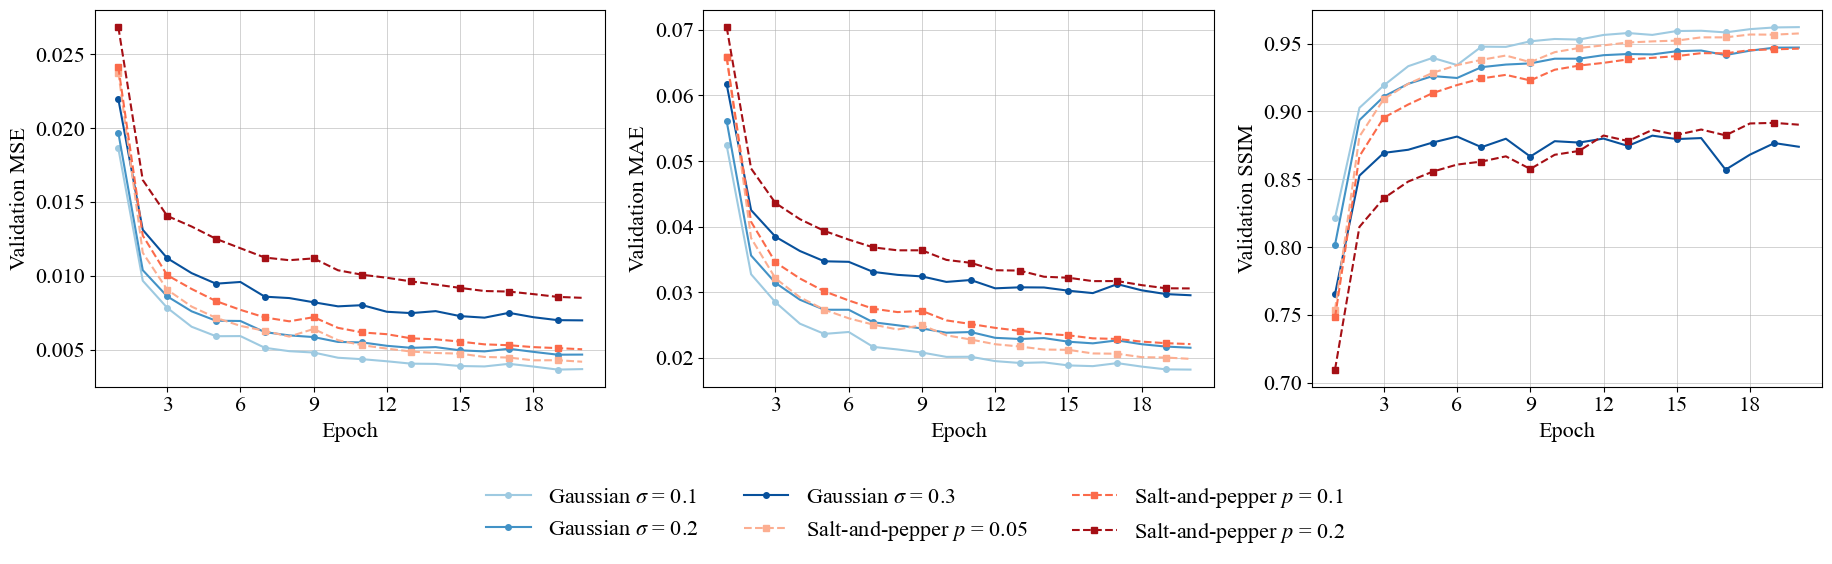

[table] table_ex2_cross_noise


MSE       MAE      SSIM
Trained on      Tested on       Level                              
Gaussian        Gaussian        0.10   0.003628  0.017888  0.961265
                                0.20   0.004548  0.021116  0.947300
                                0.30   0.006920  0.029220  0.871357
                Salt-and-pepper 0.05   0.004674  0.020774  0.934371
                                0.10   0.006676  0.026447  0.885142
                                0.20   0.012846  0.042552  0.759971
Salt-and-pepper Gaussian        0.10   0.006771  0.028585  0.893979
                                0.20   0.011997  0.045529  0.729795
                                0.30   0.019376  0.067351  0.628021
                Salt-and-pepper 0.05   0.004107  0.019506  0.957056
                                0.10   0.005048  0.021998  0.944576
                                0.20   0.008302  0.030151  0.889336

[saved] ex2_gauss_vs_sp_grid.pdf  (127.9 KB)  <- EPS was 37513.4 KB, used PDF


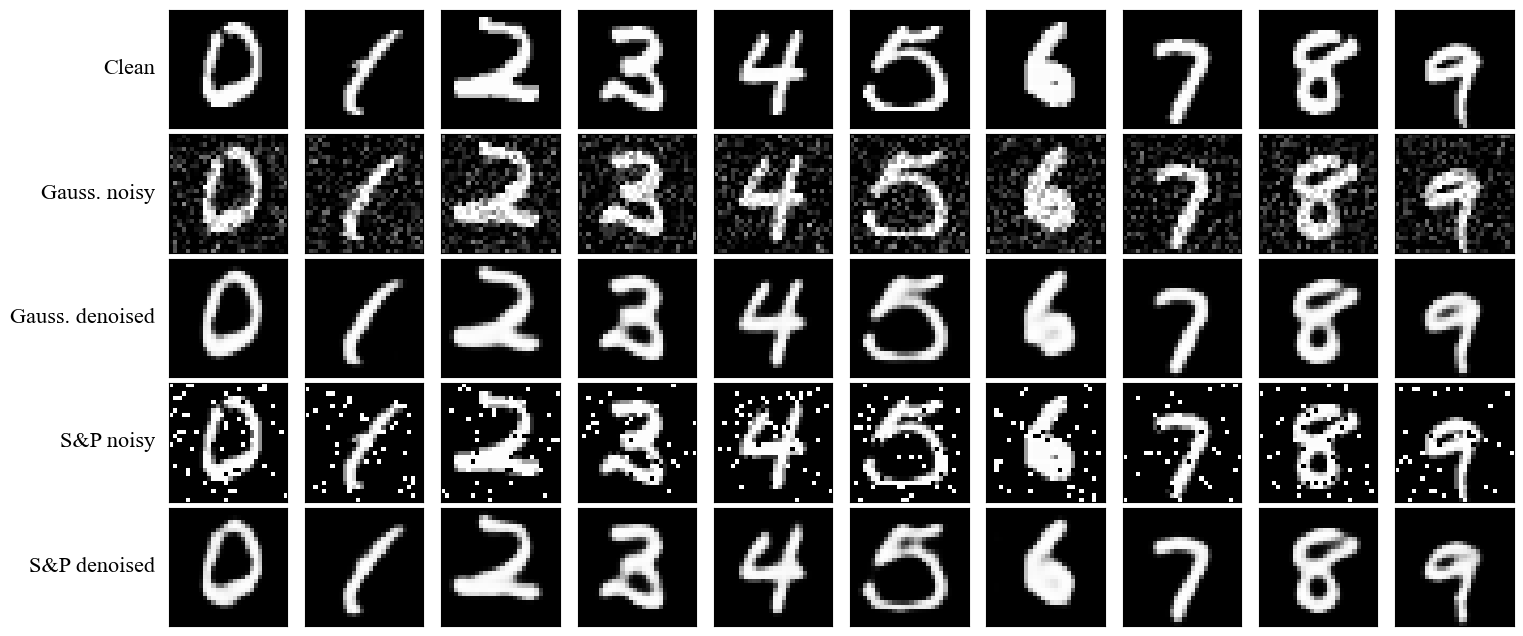

PosixPath('/content/outputs/plots/ex2_gauss_vs_sp_grid.pdf')

In [15]:
# ============================================================
# Cell 14: Exercise 2 - Gaussian vs salt-and-pepper (same architecture, Cell 9 models)
# ============================================================
# (a) epoch-wise: per-epoch validation metrics at every level of both noise types
blues = ["#9ecae1", "#4292c6", "#08519c"]; reds = ["#fcae91", "#fb6a4a", "#a50f15"]
hists, styles = {}, {}
for i, l in enumerate(NOISE["gaussian"]):
    k = rf"Gaussian $\sigma$ = {l}"
    hists[k] = eval_to_hist(HISTORIES["DCAE-gaussian"]["eval"][str(l)]); styles[k] = (blues[i], "-", "o")
for i, l in enumerate(NOISE["sp"]):
    k = rf"Salt-and-pepper $p$ = {l}"
    hists[k] = eval_to_hist(HISTORIES["DCAE-sp"]["eval"][str(l)]); styles[k] = (reds[i], "--", "s")
plot_epochwise(hists, "ex2_gauss_vs_sp_epochwise", styles=styles, ncol=3)

# (b) cross-evaluation on test set: every model on every noise type / level
rows = []
for tr_kind in ("gaussian", "sp"):
    mdl = MODELS[f"DCAE-{tr_kind}"]
    for te_kind in ("gaussian", "sp"):
        for i, lvl in enumerate(NOISE[te_kind]):
            xn = corrupt_np(x_te, te_kind, lvl, seed=TEST_SEED + i)
            rows.append({"Trained on": NAMES[tr_kind], "Tested on": NAMES[te_kind], "Level": lvl,
                         **evaluate_recon(x_te, predict(mdl, xn))})
save_table(pd.DataFrame(rows).set_index(["Trained on", "Tested on", "Level"]), "table_ex2_cross_noise")

# (c) qualitative
xg, xs = DAE["gaussian"], DAE["sp"]
show_grid([("Clean", x_te[SHOW_IDX]),
           (r"Gauss. noisy", xg["noisy"][SHOW_IDX]), ("Gauss. denoised", xg["den"][SHOW_IDX]),
           (r"S&P noisy", xs["noisy"][SHOW_IDX]), ("S&P denoised", xs["den"][SHOW_IDX])],
          "ex2_gauss_vs_sp_grid")

[trained] DCAE-gaussian-0.1: params=74,497  time=49.4s  final val_loss=0.0715
[trained] DCAE-gaussian-0.3: params=74,497  time=30.9s  final val_loss=0.0828
[saved] ex3_train_sigma_epochwise_ssim.pdf  (35.5 KB)  <- EPS was 120.8 KB, used PDF


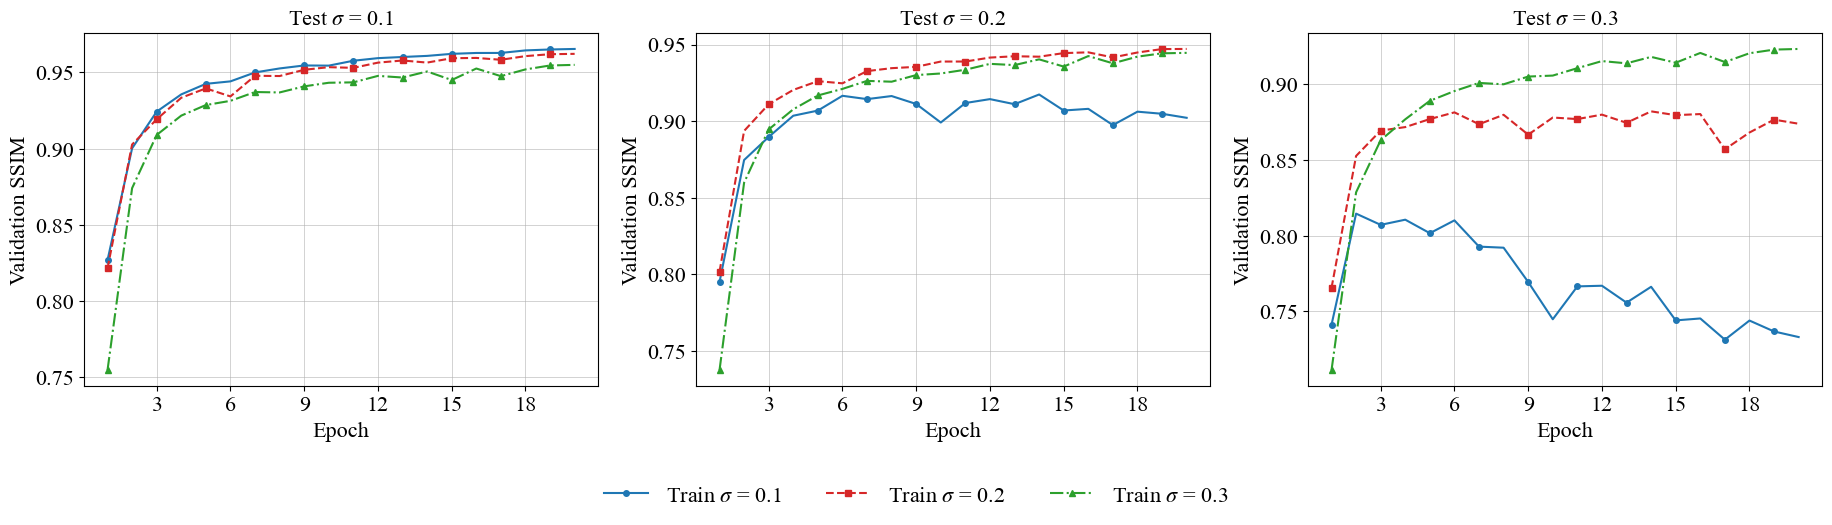

[saved] ex3_train_sigma_epochwise_mse.pdf  (34.9 KB)  <- EPS was 119.3 KB, used PDF


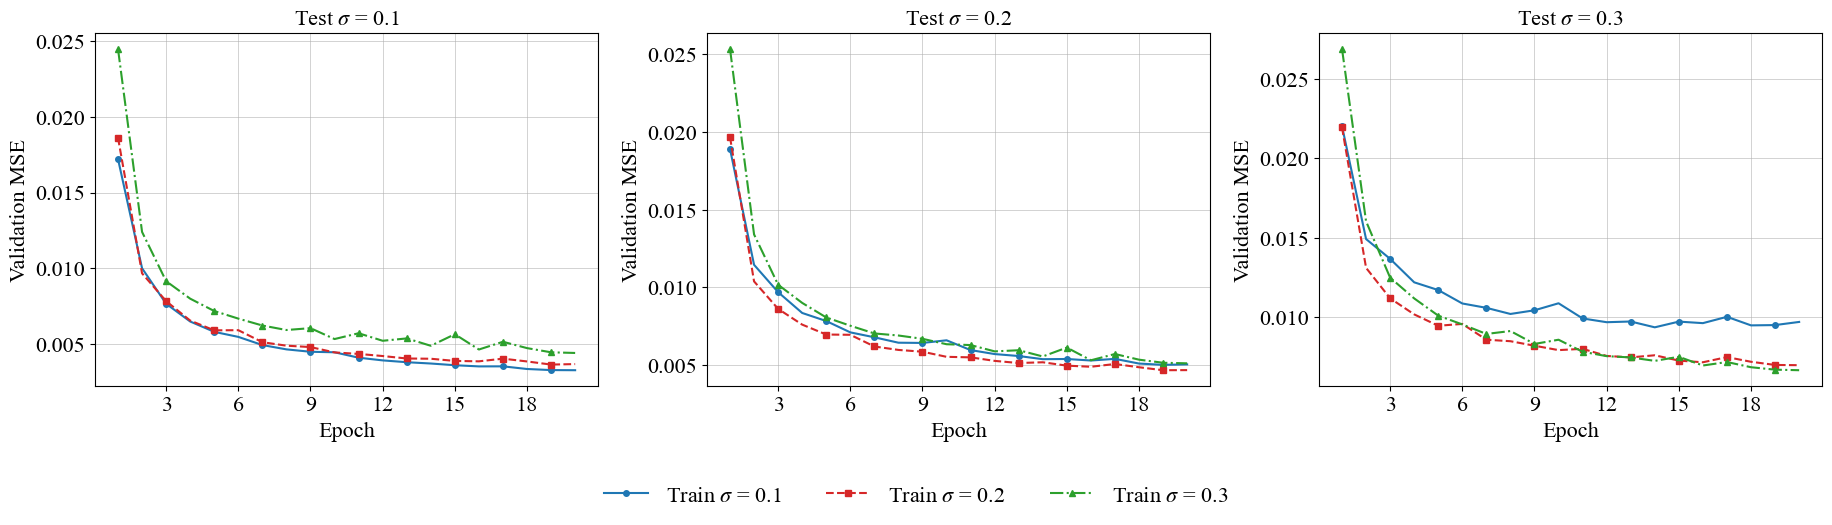

[table] table_ex3_train_vs_test_sigma


MSE       MAE      SSIM
Train sigma Test sigma                              
0.1         0.1         0.003205  0.017308  0.965387
            0.2         0.004990  0.024438  0.901497
            0.3         0.009563  0.041898  0.730197
0.2         0.1         0.003628  0.017888  0.961265
            0.2         0.004548  0.021116  0.947300
            0.3         0.006920  0.029220  0.871357
0.3         0.1         0.004317  0.019401  0.953937
            0.2         0.004967  0.021598  0.944740
            0.3         0.006516  0.026207  0.922479

[table] table_ex3_ssim_matrix


Test sigma,0.1,0.2,0.3
Train sigma,,,
0.1,0.965387,0.901497,0.730197
0.2,0.961265,0.947300,0.871357
0.3,0.953937,0.944740,0.922479


In [16]:
# ============================================================
# Cell 15: Exercise 3 - DAE trained at different sigma, tested at all sigma
# ============================================================
TRAIN_SIGMAS = [0.1, 0.2, 0.3]
name_of = lambda s: "DCAE-gaussian" if s == MAIN_NOISE["gaussian"] else f"DCAE-gaussian-{s}"

for s in TRAIN_SIGMAS:
    if s == MAIN_NOISE["gaussian"]:
        continue
    d = build_cae(None, "upsample", name=f"dcae_gauss_{s}")
    train_ae(d, name_of(s), x_tr, x_va, CFG["dae_epochs"], noise=("gaussian", s),
             extra_eval=make_eval_sets(x_va, "gaussian"))
    MODELS[name_of(s)] = d

# epoch-wise: one panel per TEST sigma, one curve per TRAIN sigma
for met, lab in (("ssim", "Validation SSIM"), ("mse", "Validation MSE")):
    fig, axes = plt.subplots(1, 3, figsize=(18.6, 4.8))
    for ax, ts in zip(axes, NOISE["gaussian"]):
        for j, s in enumerate(TRAIN_SIGMAS):
            y = HISTORIES[name_of(s)]["eval"][str(ts)][met]
            c, ls, mk = STYLES[j]
            ax.plot(np.arange(1, len(y) + 1), y, color=c, ls=ls, marker=mk, ms=4,
                    markevery=max(1, len(y) // 10), label=rf"Train $\sigma$ = {s}")
        ax.set_title(rf"Test $\sigma$ = {ts}"); ax.set_xlabel("Epoch"); ax.set_ylabel(lab)
        ax.grid(True, lw=0.4); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    fig.tight_layout(); _legend_below(fig, axes[0], 3)
    save_fig(fig, f"ex3_train_sigma_epochwise_{met}")

# final test-set table
rows = []
for s in TRAIN_SIGMAS:
    for i, ts in enumerate(NOISE["gaussian"]):
        xn = corrupt_np(x_te, "gaussian", ts, seed=TEST_SEED + i)
        rows.append({"Train sigma": s, "Test sigma": ts,
                     **evaluate_recon(x_te, predict(MODELS[name_of(s)], xn))})
long = pd.DataFrame(rows)
save_table(long.set_index(["Train sigma", "Test sigma"]), "table_ex3_train_vs_test_sigma")
save_table(long.pivot(index="Train sigma", columns="Test sigma", values="SSIM"), "table_ex3_ssim_matrix")

[trained] CAE-transpose: params=74,497  time=22.3s  final val_loss=0.0684
[table] table_ex4_decoder


,MSE,MAE,SSIM,Params,Time
Decoder,,,,,
UpSampling2D + Conv2D,0.002695,0.015512,0.973914,74497,23.567069
Conv2DTranspose,0.002331,0.014359,0.976512,74497,22.318961


[saved] ex4_decoder_epochwise.pdf  (38.6 KB)  <- EPS was 136.6 KB, used PDF


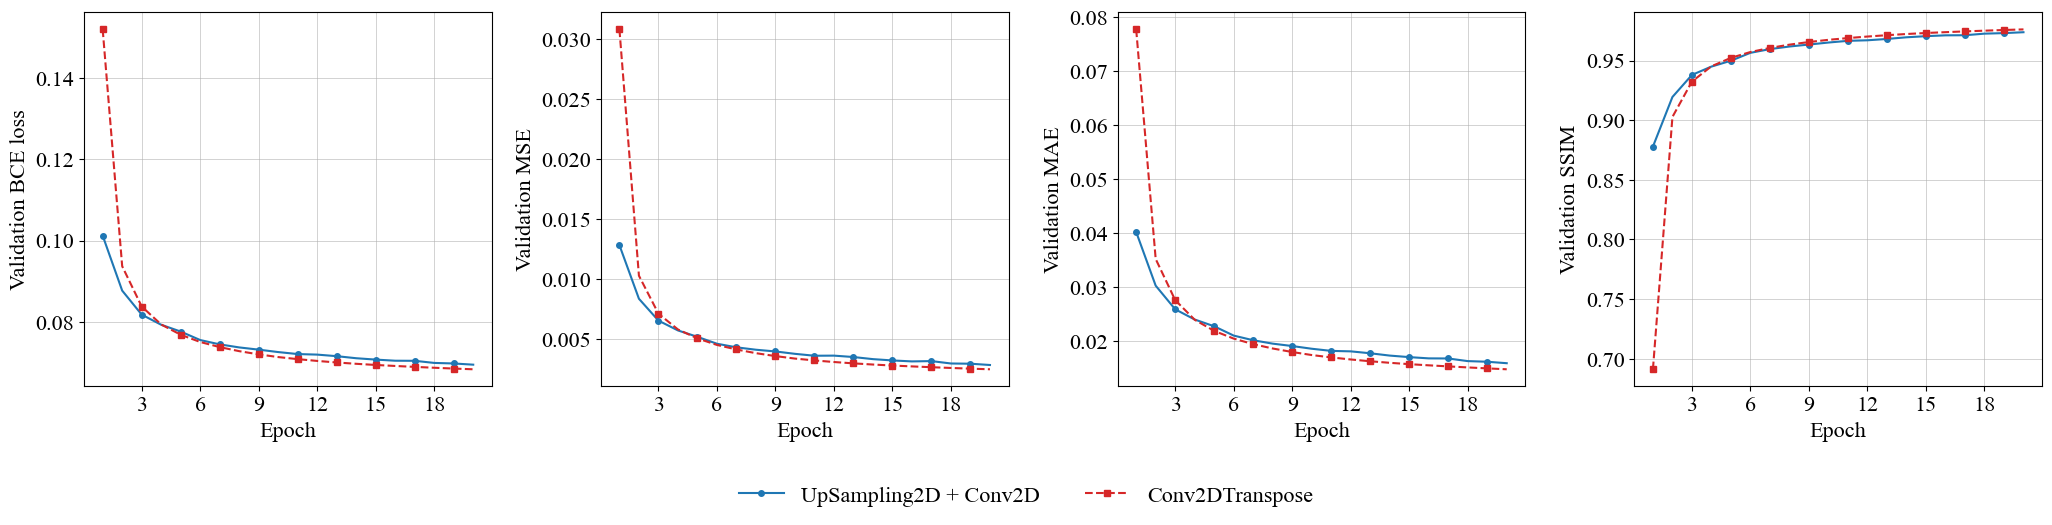

[saved] ex4_decoder_recon_grid.pdf  (77.6 KB)  <- EPS was 22787.0 KB, used PDF


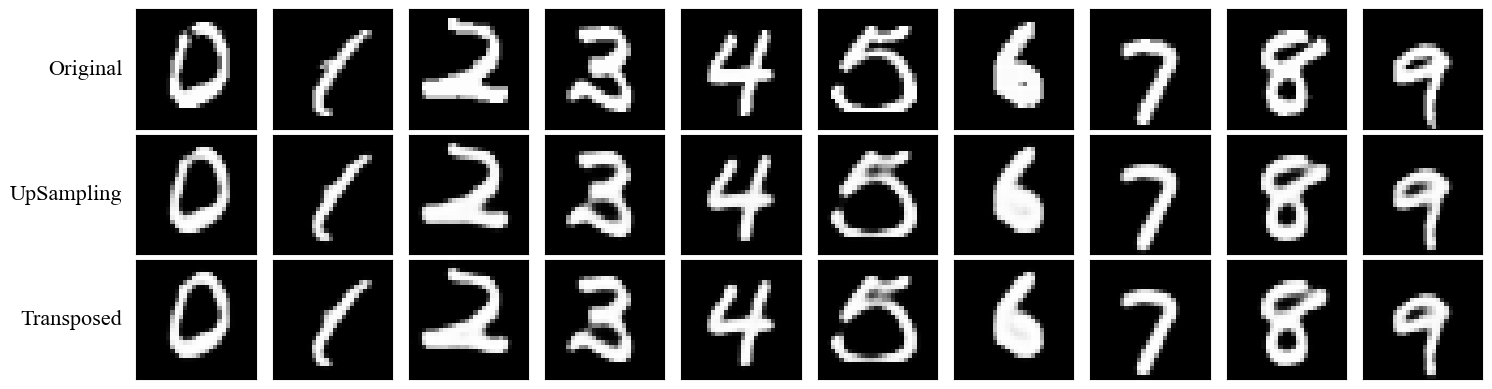

PosixPath('/content/outputs/plots/ex4_decoder_recon_grid.pdf')

In [17]:
# ============================================================
# Cell 16: Exercise 4 - Conv2DTranspose decoder vs UpSampling2D decoder
# ============================================================
cae_t = build_cae(None, "transpose", name="cae_transpose")
h_t = train_ae(cae_t, "CAE-transpose", x_tr, x_va, CFG["cae_epochs"])
MODELS["CAE-transpose"] = cae_t
xh_t = predict(cae_t, x_te); RECON["CAE-transpose"] = xh_t

df = pd.DataFrame.from_dict({
    "UpSampling2D + Conv2D": {**m_cae, "Params": count_params(cae), "Time": h_cae["time"]},
    "Conv2DTranspose": {**evaluate_recon(x_te, xh_t), "Params": count_params(cae_t), "Time": h_t["time"]}},
    orient="index")
df.index.name = "Decoder"
save_table(df, "table_ex4_decoder")

plot_epochwise({"UpSampling2D + Conv2D": HISTORIES["CAE"], "Conv2DTranspose": HISTORIES["CAE-transpose"]},
               "ex4_decoder_epochwise", keys=[("val_loss", "Validation BCE loss")] + KEYS_METRIC, panel_w=5.2)

show_grid([("Original", x_te[SHOW_IDX]), ("UpSampling", RECON["CAE"][SHOW_IDX]),
           ("Transposed", xh_t[SHOW_IDX])], "ex4_decoder_recon_grid")

[trained] VAE-dz8: params=506,321  time=28.9s  final val_loss=115.63
[table] table_ex5_vae_dz


,Rec loss,KL loss,Total loss,MSE,MAE,SSIM,Params,Time
VAE,,,,,,,,
dz = 2,147.300369,6.209250,153.509644,0.042174,0.098037,0.536250,485957,39.758388
dz = 8,98.059937,16.349163,114.409096,0.019132,0.052333,0.797114,506321,28.927780


[saved] ex5_vae_dz_epochwise.pdf  (37.4 KB)  <- EPS was 133.3 KB, used PDF


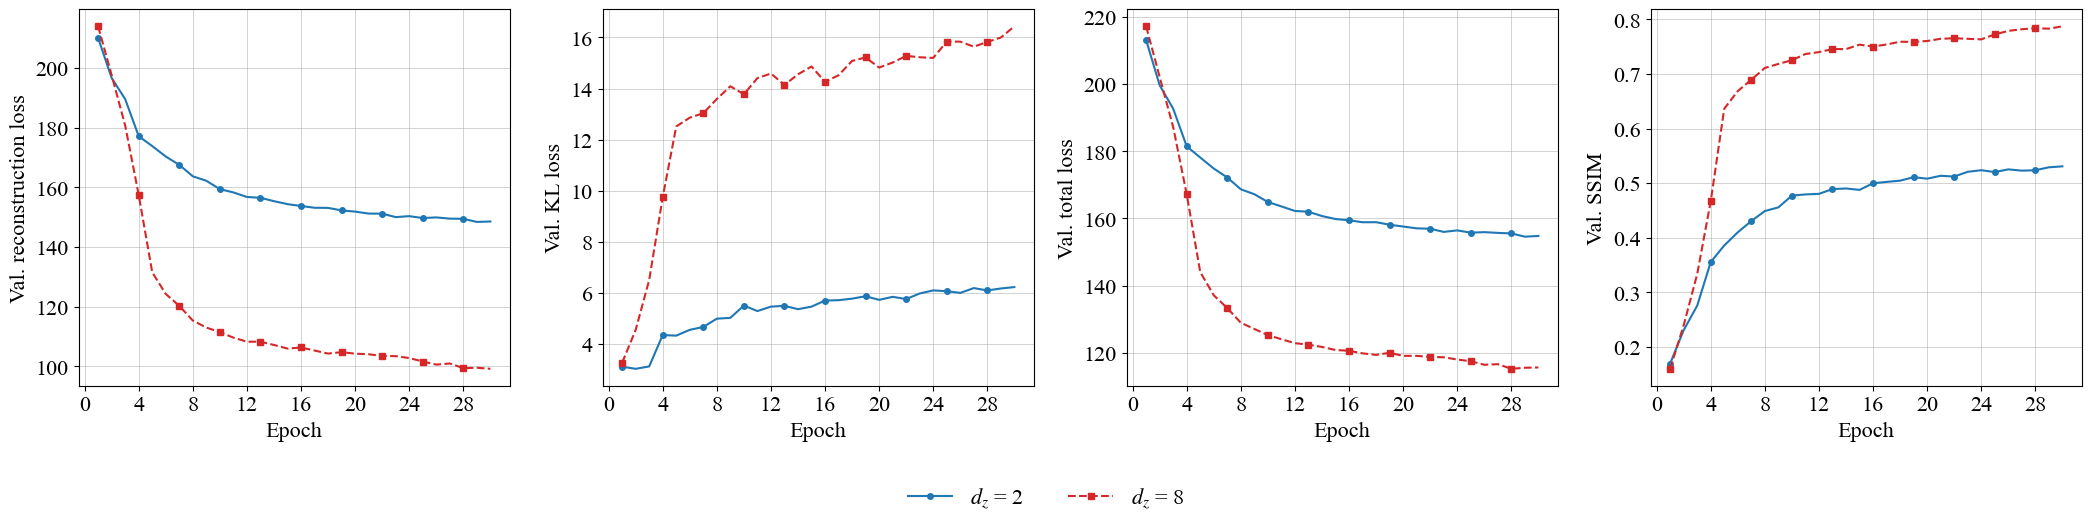

[saved] ex5_vae_dz8_latent_pca.pdf  (56.3 KB)  <- EPS was 111.3 KB, used PDF


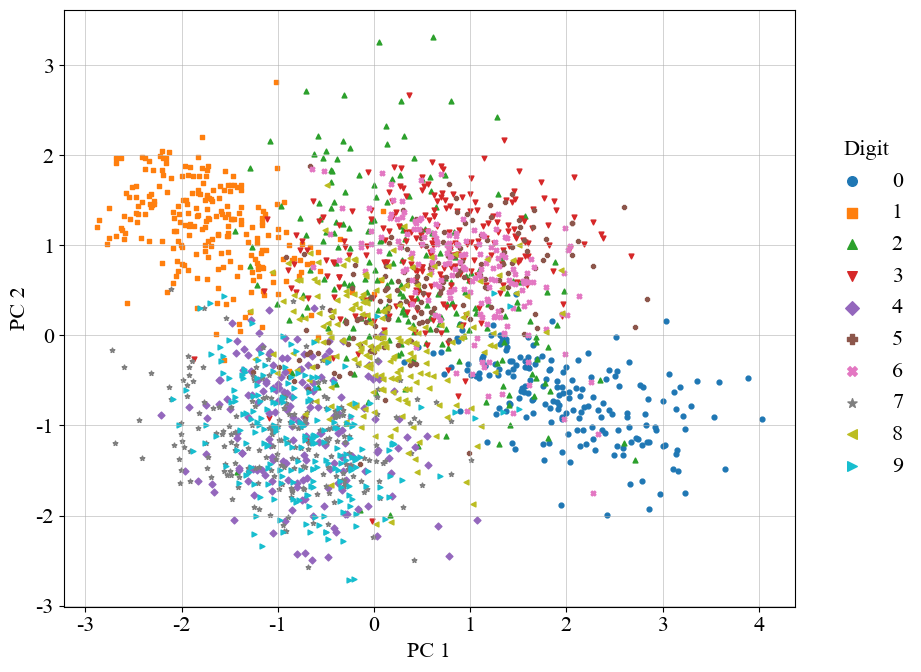

[table] table_ex5_vae_dz8_dim_stats


,std(mu),mean(sigma),KL per dim
z1,0.926806,0.090373,2.379172
z2,1.035535,0.106362,2.307229
z3,0.805795,0.316772,1.060674
z4,1.056644,0.112247,2.263336
z5,0.931207,0.133102,1.989257
z6,0.994434,0.099595,2.328763
z7,1.058217,0.105203,2.339956
z8,0.912606,0.179033,1.680782


PCA explained variance ratio: [0.205 0.153]
[saved] ex5_vae_dz8_generated.pdf  (26.2 KB)  <- EPS was 9540.3 KB, used PDF


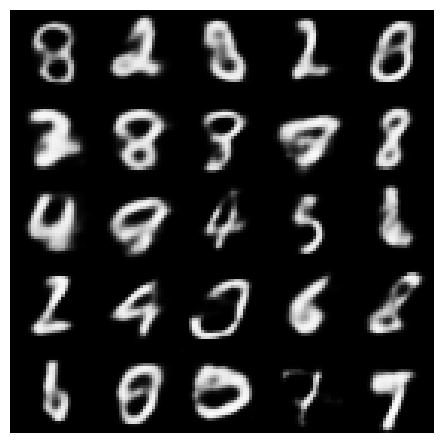

PosixPath('/content/outputs/plots/ex5_vae_dz8_generated.pdf')

In [18]:
# ============================================================
# Cell 17: Exercise 5 - VAE latent dimension 2 vs 8
# ============================================================
vae8, h_vae8 = train_vae(8, 1.0, "VAE-dz8")
MODELS["VAE-dz8"] = vae8
m8, xh8 = evaluate_vae(vae8, x_te); RECON["VAE-dz8"] = xh8

df = pd.DataFrame.from_dict({
    "dz = 2": {**m_vae, "Params": count_vae_params(vae), "Time": h_vae["time"]},
    "dz = 8": {**m8, "Params": count_vae_params(vae8), "Time": h_vae8["time"]}}, orient="index")
df.index.name = "VAE"
save_table(df, "table_ex5_vae_dz")

# epoch-wise comparison
plot_epochwise({r"$d_z$ = 2": HISTORIES["VAE"], r"$d_z$ = 8": HISTORIES["VAE-dz8"]},
               "ex5_vae_dz_epochwise",
               keys=[("val_rec_loss", "Val. reconstruction loss"), ("val_kl_loss", "Val. KL loss"),
                     ("val_loss", "Val. total loss"), ("val_ssim", "Val. SSIM")], panel_w=5.3)

# dz = 8 latent space: PCA of the encoded means + per-dimension statistics
MU8, LV8, _ = [np.asarray(a) for a in vae8.encoder.predict(x_te, batch_size=256, verbose=0)]
pc = PCA(n_components=2, random_state=SEED).fit(MU8)
P = pc.transform(MU8)
fig, ax = plt.subplots(figsize=(9.5, 7))
scatter_latent(ax, P, y_te)
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.grid(True, lw=0.4)
ax.legend(title="Digit", loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2)
fig.tight_layout(); save_fig(fig, "ex5_vae_dz8_latent_pca")

kl8 = -0.5 * np.mean(1 + LV8 - MU8 ** 2 - np.exp(LV8), axis=0)
save_table(pd.DataFrame({"std(mu)": MU8.std(0), "mean(sigma)": np.exp(0.5 * LV8).mean(0),
                         "KL per dim": kl8}, index=[f"z{j+1}" for j in range(8)]),
           "table_ex5_vae_dz8_dim_stats")
print("PCA explained variance ratio:", np.round(pc.explained_variance_ratio_, 3))

# generated samples from dz = 8
Z8 = np.random.default_rng(SEED).standard_normal((25, 8)).astype("float32")
gallery(np.asarray(vae8.decoder.predict(Z8, verbose=0)), 5, 5, "ex5_vae_dz8_generated", cell=1.1)

[trained] VAE-beta0.5: params=485,957  time=34.0s  final val_loss=152.80
[trained] VAE-beta2.0: params=485,957  time=29.0s  final val_loss=162.09
[trained] VAE-beta5.0: params=485,957  time=28.4s  final val_loss=174.76
[table] table_ex6_kl_weight


,Rec loss,KL loss,Total loss,MSE,MAE,SSIM,Params,Time
Beta,,,,,,,,
0.5,147.452606,7.026873,150.966049,0.042345,0.098483,0.536317,485957,34.046065
1.0,147.221161,6.209250,153.430420,0.042174,0.098037,0.536250,485957,39.758388
2.0,151.297379,4.907893,161.113159,0.043470,0.102055,0.514672,485957,28.964634
5.0,156.036179,3.418058,173.126465,0.044030,0.104658,0.498738,485957,28.410108


[saved] ex6_kl_weight_epochwise.pdf  (39.4 KB)  <- EPS was 132.1 KB, used PDF


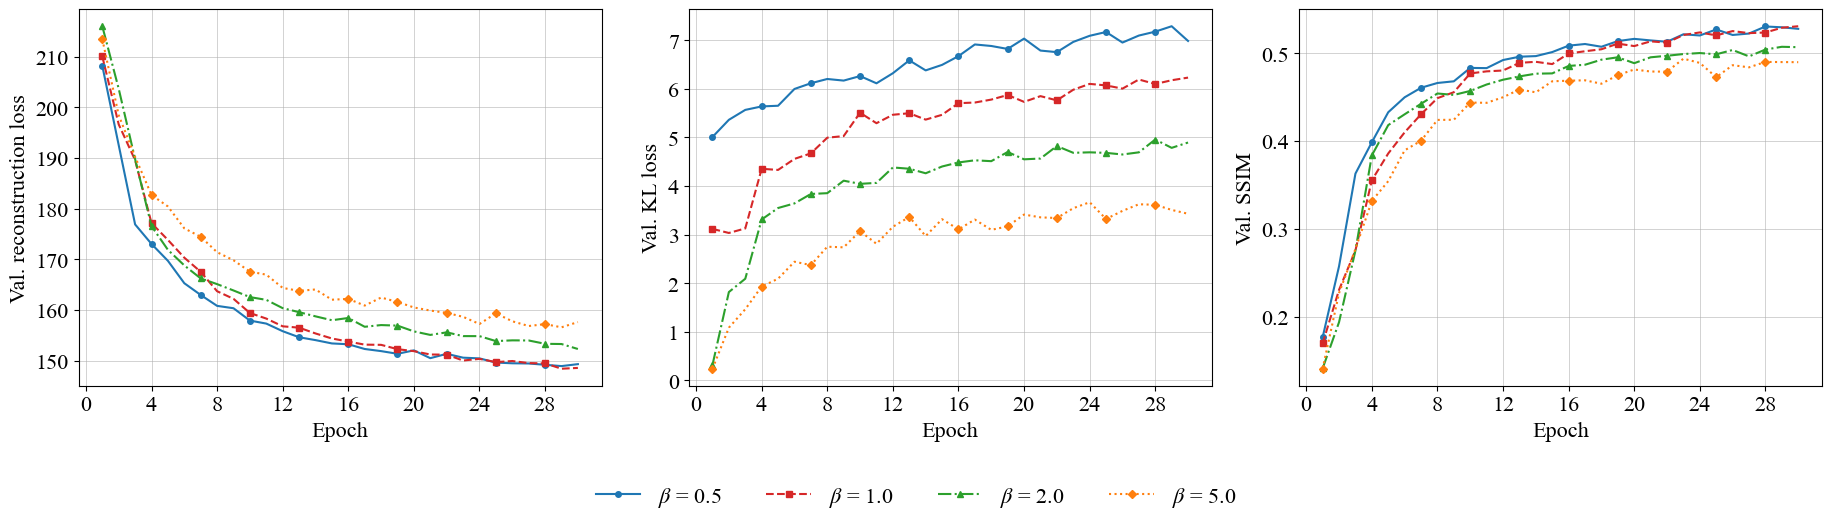

[saved] ex6_kl_weight_latent.pdf  (161.3 KB)  <- EPS was 248.4 KB, used PDF


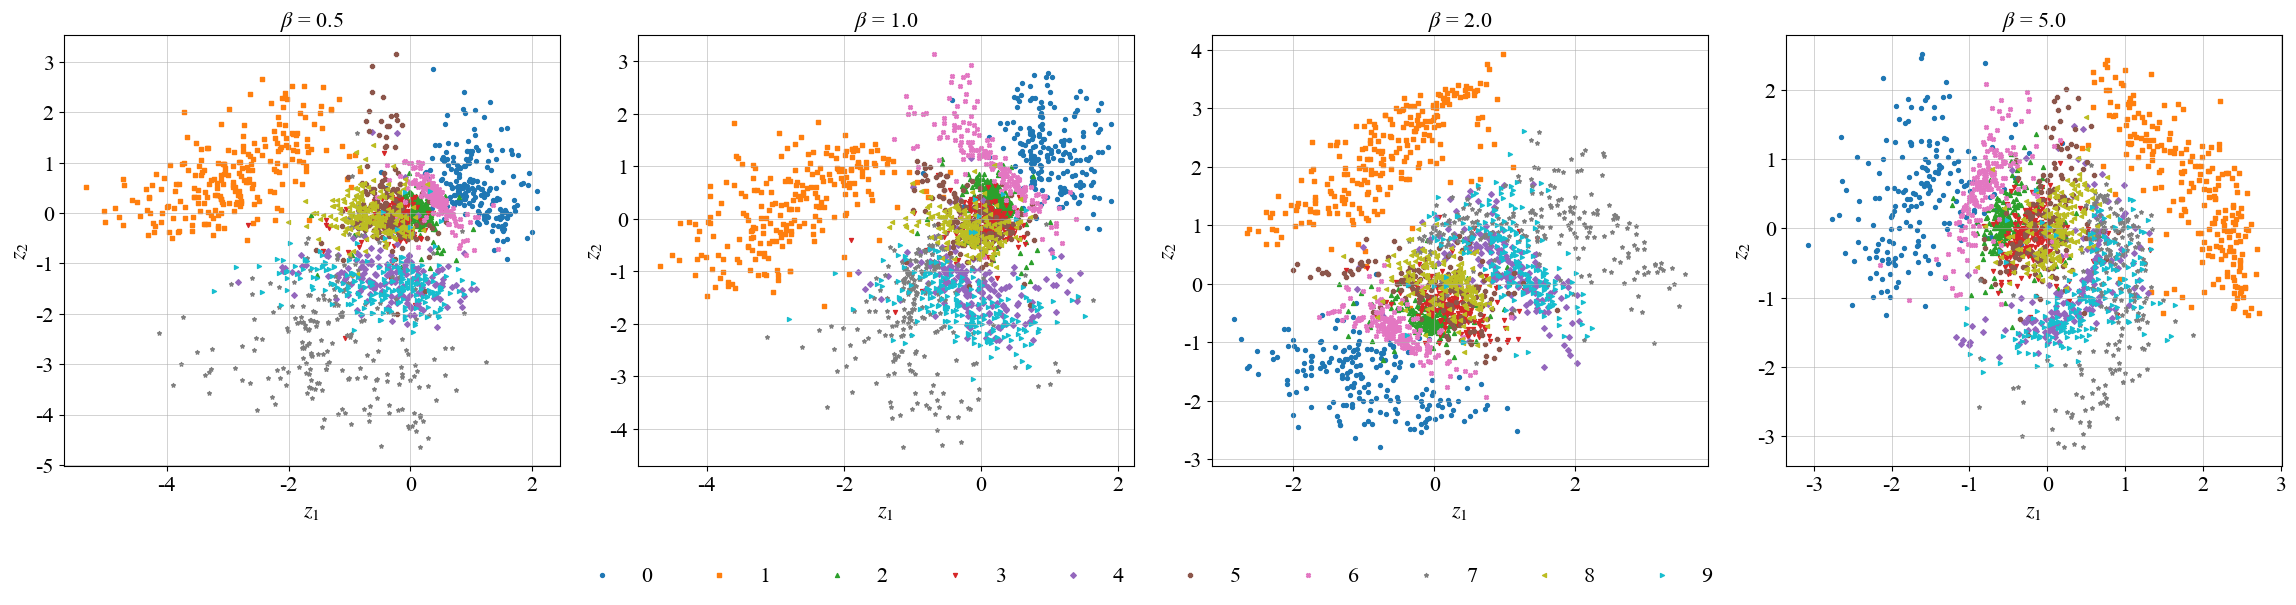

[saved] ex6_kl_weight_generated.pdf  (133.2 KB)  <- EPS was 35806.8 KB, used PDF


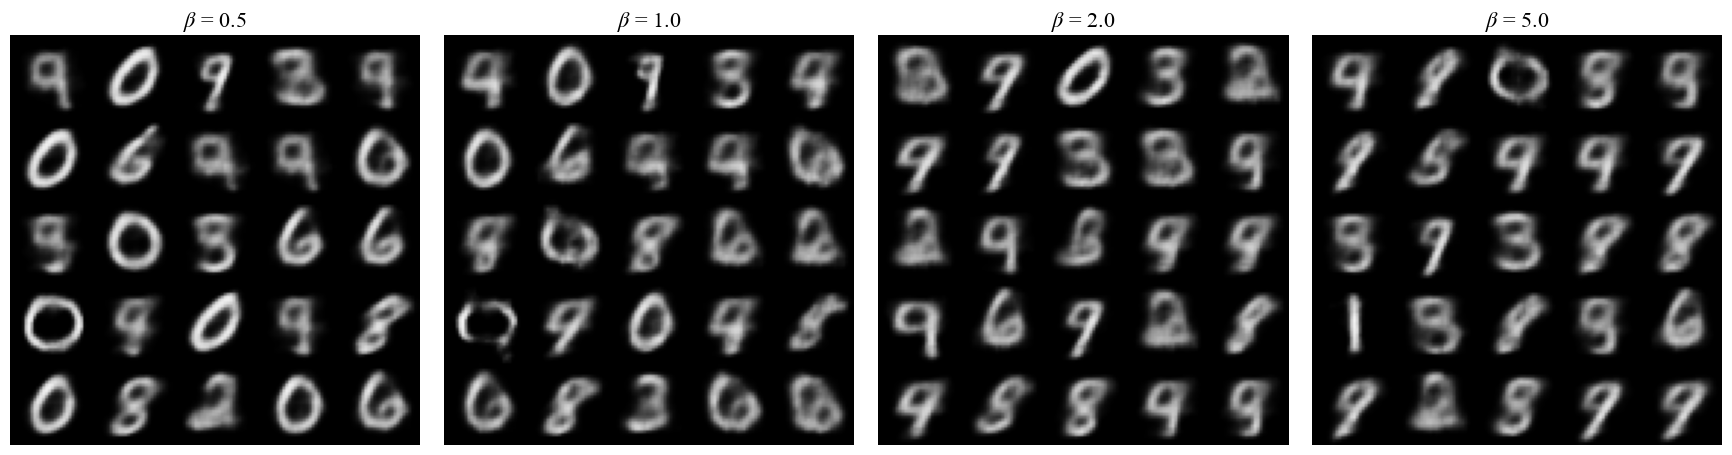

PosixPath('/content/outputs/plots/ex6_kl_weight_generated.pdf')

In [19]:
# ============================================================
# Cell 18: Exercise 6 - KL weight beta in {0.5, 1, 2, 5}, dz = 2
# ============================================================
BETA = {}
for b in CFG["kl_weights"]:
    if b == 1.0:
        vb, hb = MODELS["VAE"], HISTORIES["VAE"]
    else:
        vb, hb = train_vae(DZ, b, f"VAE-beta{b}"); MODELS[f"VAE-beta{b}"] = vb
    m, _ = evaluate_vae(vb, x_te)
    mu = np.asarray(vb.encoder.predict(x_te, batch_size=256, verbose=0)[0])
    BETA[b] = dict(model=vb, hist=hb, mu=mu, m=m, params=count_vae_params(vb), time=hb["time"])

df = pd.DataFrame.from_dict({b: {**r["m"], "Params": r["params"], "Time": r["time"]}
                             for b, r in BETA.items()}, orient="index")
df.index.name = "Beta"
save_table(df, "table_ex6_kl_weight")

# epoch-wise (total loss is beta-weighted, so it is not comparable across runs and is omitted)
plot_epochwise({rf"$\beta$ = {b}": r["hist"] for b, r in BETA.items()}, "ex6_kl_weight_epochwise",
               keys=[("val_rec_loss", "Val. reconstruction loss"), ("val_kl_loss", "Val. KL loss"),
                     ("val_ssim", "Val. SSIM")])

# latent scatter per beta
fig, axes = plt.subplots(1, len(BETA), figsize=(5.8 * len(BETA), 5.6))
for ax, (b, r) in zip(axes, BETA.items()):
    scatter_latent(ax, r["mu"], y_te, s=8)
    ax.set_title(rf"$\beta$ = {b}"); ax.set_xlabel(r"$z_1$"); ax.set_ylabel(r"$z_2$"); ax.grid(True, lw=0.4)
fig.tight_layout(); _legend_below(fig, axes[-1], 10)
save_fig(fig, "ex6_kl_weight_latent")

# generated samples per beta (same z for all)
Zb = np.random.default_rng(SEED).standard_normal((25, DZ)).astype("float32")
fig, axes = plt.subplots(1, len(BETA), figsize=(4.4 * len(BETA), 4.8))
for ax, (b, r) in zip(axes, BETA.items()):
    ax.imshow(make_canvas(np.asarray(r["model"].decoder.predict(Zb, verbose=0)), 5, 5),
              cmap="gray", vmin=0, vmax=1)
    ax.set_title(rf"$\beta$ = {b}"); ax.axis("off")
fig.tight_layout(); save_fig(fig, "ex6_kl_weight_generated")

[saved] ex7_vae_random_15x15.pdf  (176.2 KB)  <- EPS was 25524.4 KB, used PDF


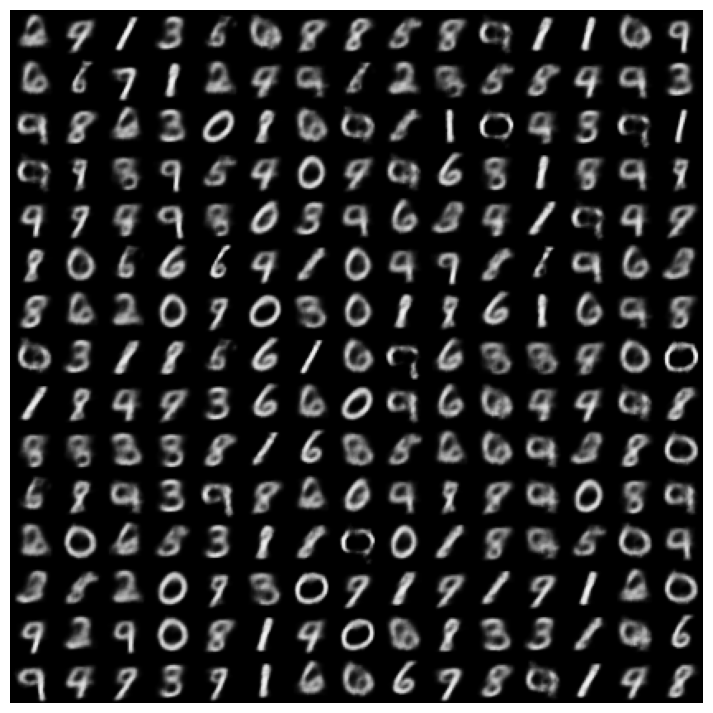

[saved] ex7_vae_latent_manifold.pdf  (178.1 KB)  <- EPS was 25524.4 KB, used PDF


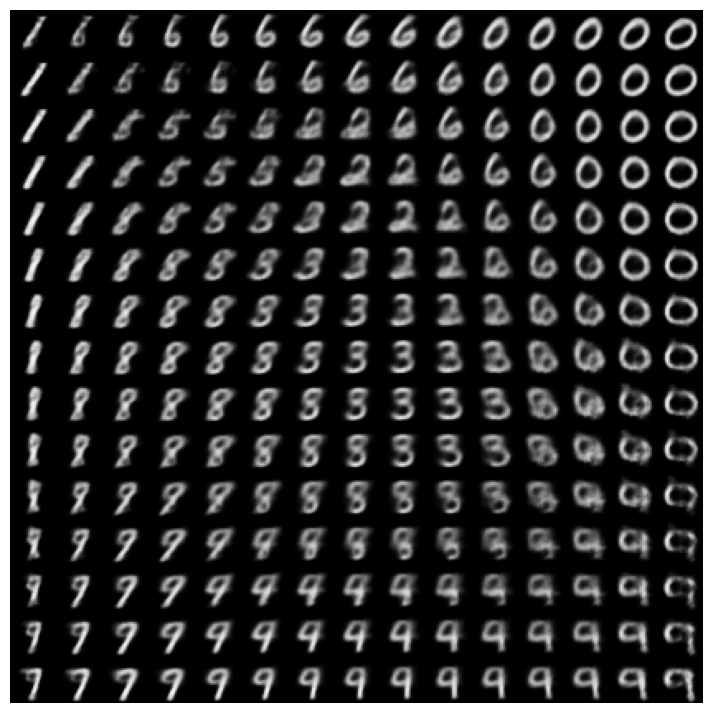

[saved] ex8_class_interpolation.pdf  (94.7 KB)  <- EPS was 25896.3 KB, used PDF


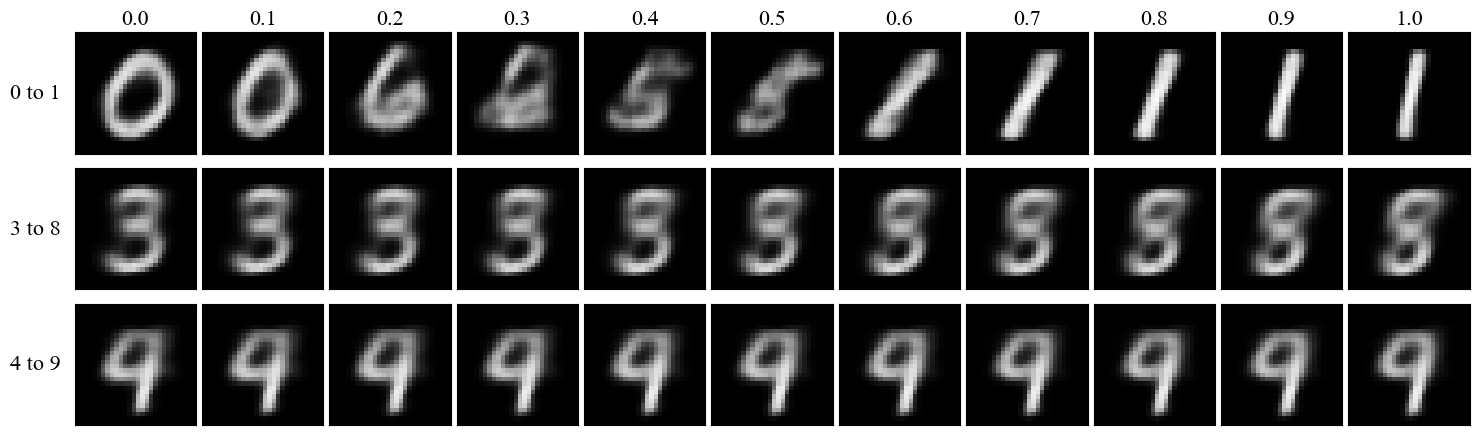

PosixPath('/content/outputs/plots/ex8_class_interpolation.pdf')

In [20]:
# ============================================================
# Cell 19: Exercise 7 (larger sample grid + manifold) and Exercise 8 (class-to-class interpolation)
# ============================================================
# --- Exercise 7 ---
Zbig = np.random.default_rng(SEED + 1).standard_normal((225, DZ)).astype("float32")
gallery(np.asarray(vae.decoder.predict(Zbig, batch_size=225, verbose=0)), 15, 15,
        "ex7_vae_random_15x15", cell=0.6)

n = 15
g = norm.ppf(np.linspace(0.05, 0.95, n))
zs = np.array([[gx, gy] for gy in g[::-1] for gx in g], dtype="float32")   # rows: z2 high -> low
gallery(np.asarray(vae.decoder.predict(zs, batch_size=225, verbose=0)), n, n,
        "ex7_vae_latent_manifold", cell=0.6)

# --- Exercise 8: interpolate between class-mean latent vectors ---
class_mu = {d: MU_TE[y_te == d].mean(0) for d in range(10)}
PAIRS = [(0, 1), (3, 8), (4, 9)]
rows = [(f"{a} to {b}", interpolate(vae.decoder, class_mu[a], class_mu[b], alphas)) for a, b in PAIRS]
show_grid(rows, "ex8_class_interpolation", col_titles=[f"{a:.1f}" for a in alphas], cell=1.5)

In [21]:
# ============================================================
# Cell 20: Save histories/results and zip everything
# ============================================================
import shutil
from google.colab import files

conv = lambda o: float(o) if isinstance(o, (np.floating, np.integer)) else str(o)
json.dump(HISTORIES, open("/content/outputs/histories.json", "w"), default=conv)
json.dump(RESULTS, open("/content/outputs/results.json", "w"), default=conv)

print(f"{len(list(OUT_DIR.glob('*.eps')))} EPS, {len(list(OUT_DIR.glob('*.pdf')))} PDF, "
      f"{len(list(TAB_DIR.glob('*.tex')))} LaTeX tables")
shutil.make_archive("/content/lab7_outputs", "zip", "/content/outputs")
files.download("/content/lab7_outputs.zip")

2 EPS, 40 PDF, 20 LaTeX tables


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>